In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import os
import pandas as pd

In [3]:
from src.loader import load_all_samples
from src.filter import filter_data
from src.filter import normalize_and_select_genes
from src.clustering import run_pca
from src.clustering import run_clustering

Is index unique? True
Number of mitochondrial genes detected: 13

QC metrics added to adata.obs:
['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']

QC Statistics:


,total_counts,n_genes_by_counts,pct_counts_mt
count,34078.000000,34078.000000,34078.000000
mean,630.604492,2290.729415,2.499186
std,61.527061,1018.252556,0.938393
min,119.023888,203.000000,0.000000
25%,592.297119,1672.000000,2.106632
50%,633.059692,2122.000000,2.416822
75%,674.417587,2642.000000,2.746958
max,802.334778,10984.000000,40.870228


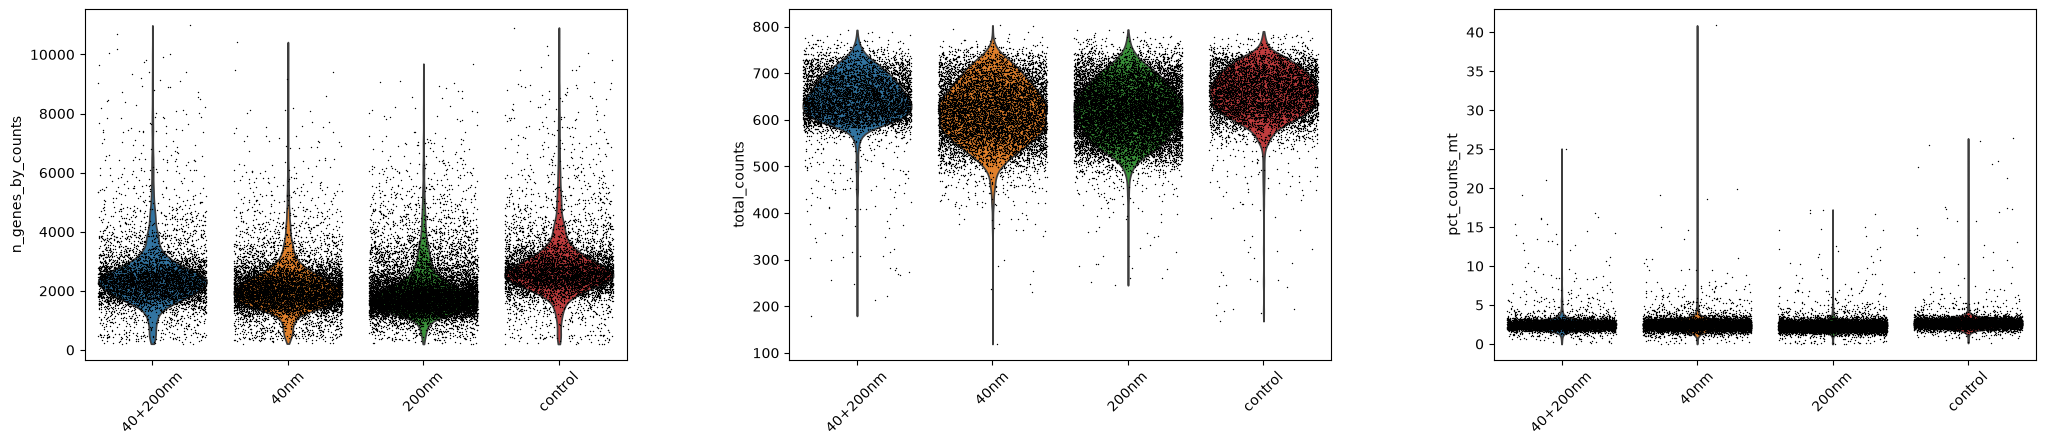

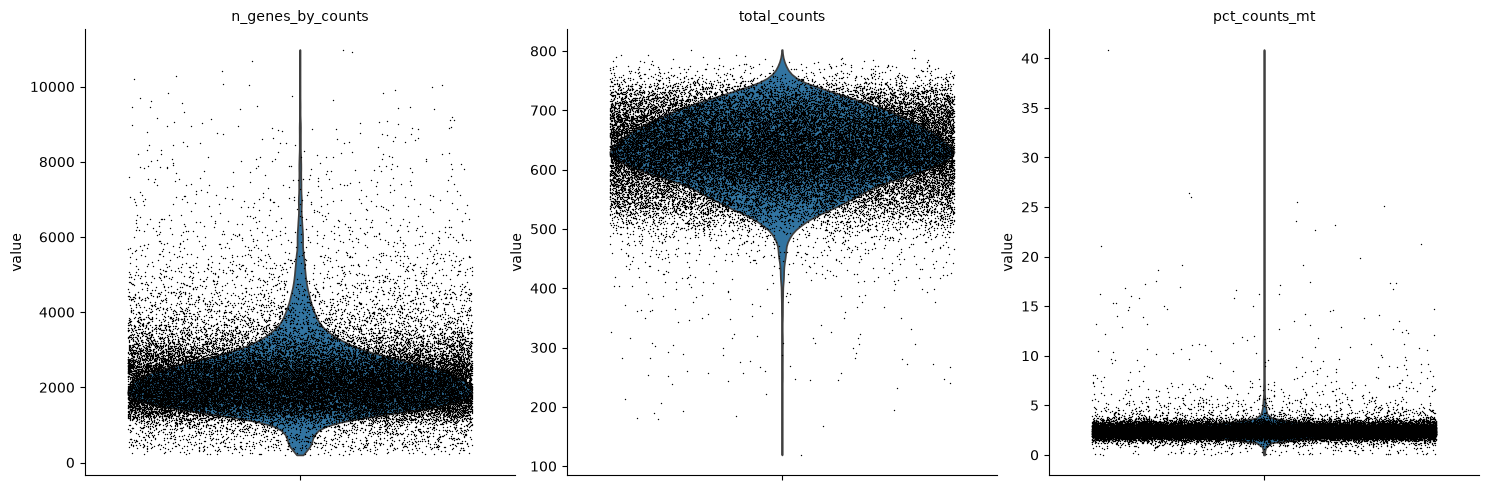

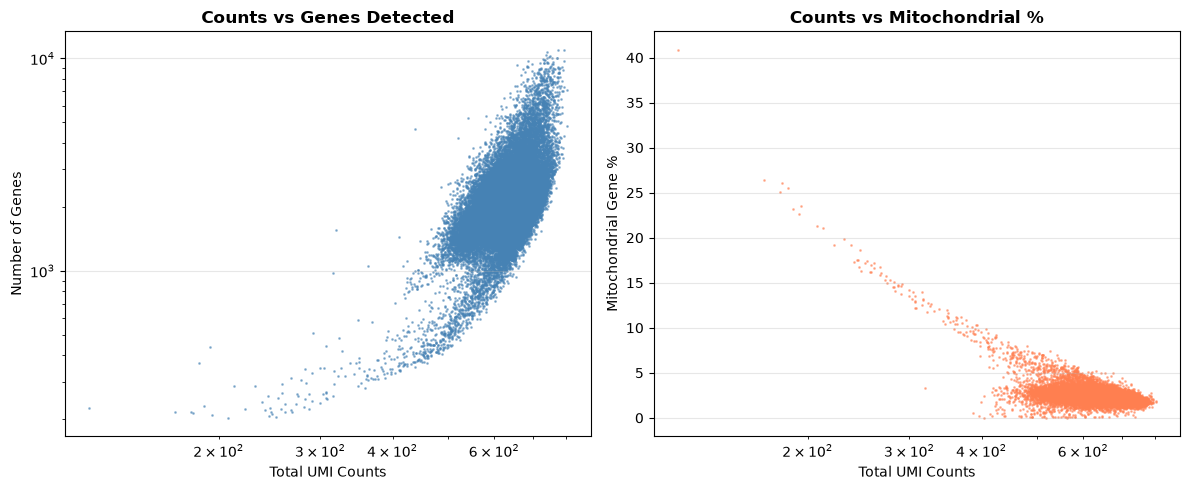


✓ QC scatter plots generated
Number of cells | Number of genes found in exactly that many cells
----------------|-----------------------------------------------
3     754
4     321
5     171
6     290
7     261
8     195
9     203
10    180
11    159
12    160
Name: count, dtype: int64
Stats BEFORE filtering: 34078 cells, 24380 genes
Stats AFTER filtering: 31767 cells, 24380 genes
Step 1: Saving raw counts...
Step 2: Normalizing total counts...
Step 3: Log-transforming...
Step 4: Identifying Highly Variable Genes (HVGs)...
Number of HVGs after excluding MT/Ribo: 2487


In [3]:
# Read H5AD file
adata = load_all_samples()

print(f"Is index unique? {adata.obs.index.is_unique}")

adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print(f"Number of mitochondrial genes detected: {adata.var['mt'].sum()}")
print(f"\nQC metrics added to adata.obs:")
print([col for col in adata.obs.columns if col.startswith(('total_counts', 'n_genes', 'pct_counts'))])
# Display summary statistics
print("\nQC Statistics:")
qc_stats = adata.obs[['total_counts', 'n_genes_by_counts', 'pct_counts_mt']].describe()
display(qc_stats)

# Calculate QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True, show=False, groupby='sample_id', rotation=45)
plt.savefig('results/qc_scatter_feature.png', bbox_inches='tight')

# Calculate QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True, show=False)
plt.savefig('results/qc_scatter.png',bbox_inches='tight')
# Scatter plots to identify outliers and correlations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Total counts vs genes detected
axes[0].scatter(
    adata.obs['total_counts'],
    adata.obs['n_genes_by_counts'],
    alpha=0.5,
    s=1,
    c='steelblue'
)
axes[0].set_xlabel('Total UMI Counts', fontsize=10)
axes[0].set_ylabel('Number of Genes', fontsize=10)
axes[0].set_title('Counts vs Genes Detected', fontsize=12, fontweight='bold')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Total counts vs mitochondrial percentage
axes[1].scatter(
    adata.obs['total_counts'],
    adata.obs['pct_counts_mt'],
    alpha=0.5,
    s=1,
    c='coral'
)
axes[1].set_xlabel('Total UMI Counts', fontsize=10)
axes[1].set_ylabel('Mitochondrial Gene %', fontsize=10)
axes[1].set_title('Counts vs Mitochondrial %', fontsize=12, fontweight='bold')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ QC scatter plots generated")
# Calculate how many cells each gene appears in
gene_occurrence = (adata.X > 0).sum(axis=0)
if hasattr(gene_occurrence, 'A1'): gene_occurrence = gene_occurrence.A1

import pandas as pd
# Create a frequency table for the first 10 values
counts = pd.Series(gene_occurrence).value_counts().sort_index().head(10)

print("Number of cells | Number of genes found in exactly that many cells")
print("----------------|-----------------------------------------------")
print(counts)
adata = filter_data(adata, 500, 4000, 5)
adata = normalize_and_select_genes(adata)
adata.write('data/adata_preprocessed.h5ad', compression='gzip')

/usr/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


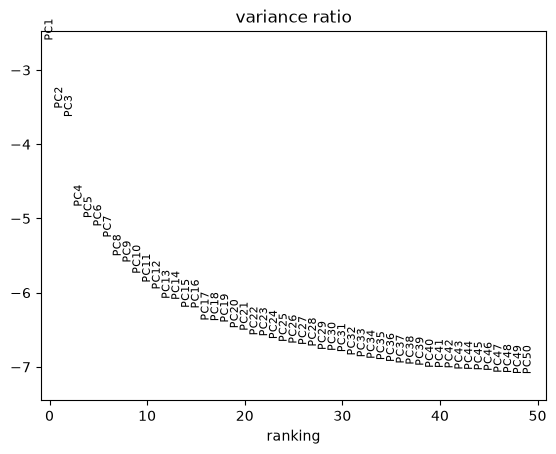

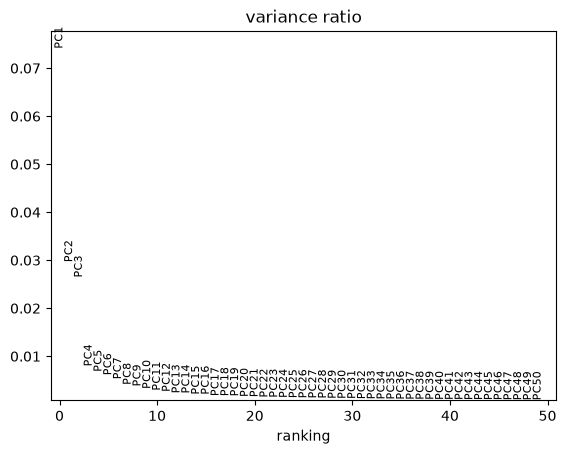

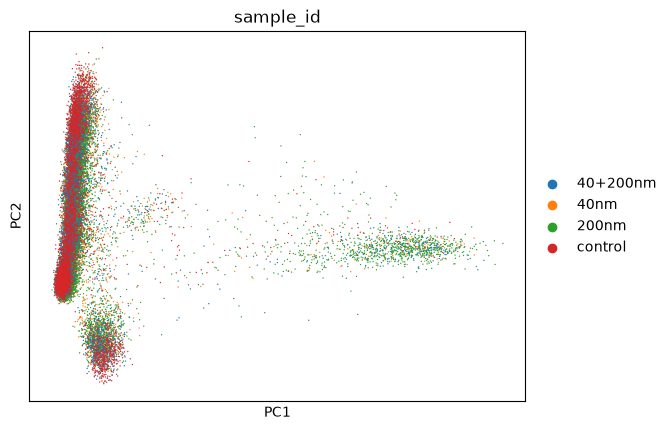


Variance explained by first 10 PCs: 16.70%
Variance explained by first 30 PCs: 20.03%


2026-08-10 15:27:06.933193: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-10 15:27:06.936935: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-10 15:27:06.947971: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-10 15:27:06.968744: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-10 15:27:06.974856: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-10 15:27:08.215696: W tensorflow/compiler/tf2tensorrt/utils/p

/home/jovan/Documents/gi/gi-2026/src/clustering.py:46: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


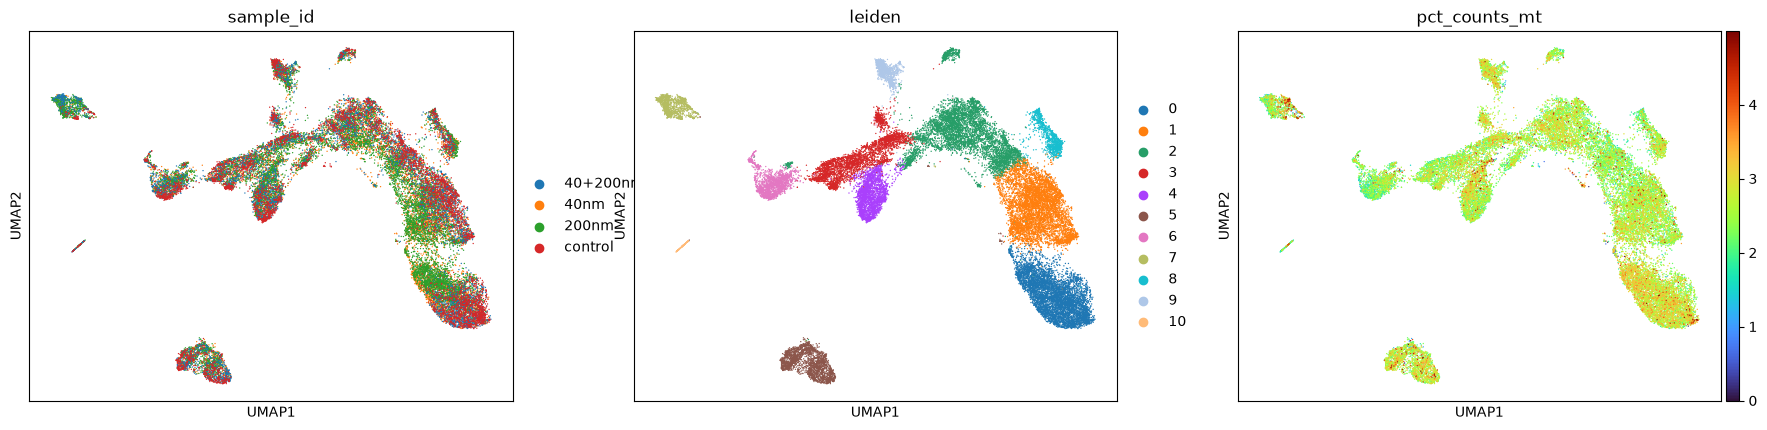

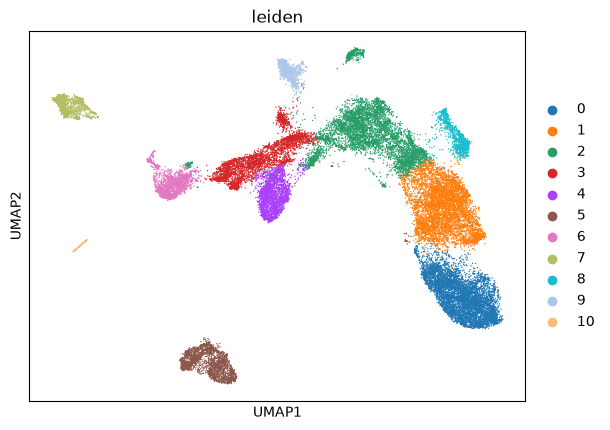

✓ Marker genes computed for Leiden clusters
  - Method: wilcoxon
  - Clusters analyzed: 11


In [4]:
adata = sc.read_h5ad('data/adata_preprocessed.h5ad')
adata = run_pca(adata)
# Calculate variance explained by each PC
variance_ratio = adata.uns['pca']['variance_ratio']
print(f"\nVariance explained by first 10 PCs: {100 * variance_ratio[:10].sum():.2f}%")
print(f"Variance explained by first 30 PCs: {100 * variance_ratio[:30].sum():.2f}%")
adata = run_clustering(adata, n_pcs=50, resolution=0.5)

n_clusters = adata.obs['leiden'].nunique()
# Find marker genes for Leiden clusters
sc.tl.rank_genes_groups(
    adata,
    groupby='leiden',  # Group by Leiden clusters
    method='wilcoxon',  # Statistical test method - does not assume normal distribution, compares medians rather than mean
    key_added='rank_genes_leiden',
    use_raw=False,
    layer='norm_log'
)

print("✓ Marker genes computed for Leiden clusters")
print(f"  - Method: wilcoxon")
print(f"  - Clusters analyzed: {n_clusters}")

adata.write('data/adata_clustered.h5ad', compression='gzip')


✓ Marker genes overview plot generated

Top 5 marker genes per cluster:

Cluster 0:
  NELL2           | score:  79.19 | logFC:   2.54 | p-val: 0.00e+00
  THEMIS          | score:  72.50 | logFC:   2.30 | p-val: 0.00e+00
  EEF1B2          | score:  68.88 | logFC:   1.22 | p-val: 0.00e+00
  CCR7            | score:  65.38 | logFC:   1.95 | p-val: 0.00e+00
  LEF1            | score:  64.80 | logFC:   2.11 | p-val: 0.00e+00

Cluster 1:
  EEF1B2          | score:  65.44 | logFC:   1.15 | p-val: 0.00e+00
  LTB             | score:  62.28 | logFC:   1.76 | p-val: 0.00e+00
  ANK3            | score:  60.58 | logFC:   2.22 | p-val: 0.00e+00
  FHIT            | score:  60.52 | logFC:   3.02 | p-val: 0.00e+00
  PLCL1           | score:  59.88 | logFC:   2.25 | p-val: 0.00e+00

Cluster 10:
  ATP10D          | score:  23.30 | logFC:   7.45 | p-val: 4.79e-120
  SIPA1L1         | score:  22.69 | logFC:   4.30 | p-val: 5.75e-114
  GAB2            | score:  22.66 | logFC:   5.12 | p-val: 1.03e-113
  P

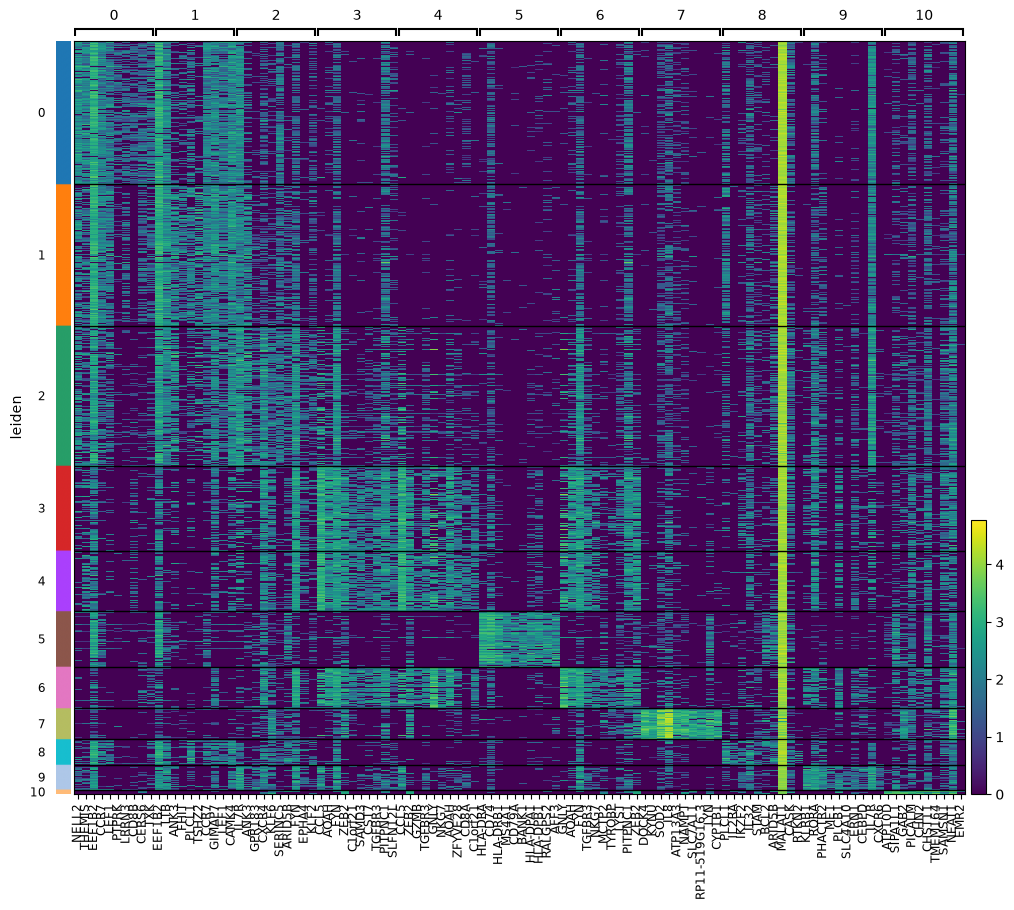


✓ Marker genes heatmap generated


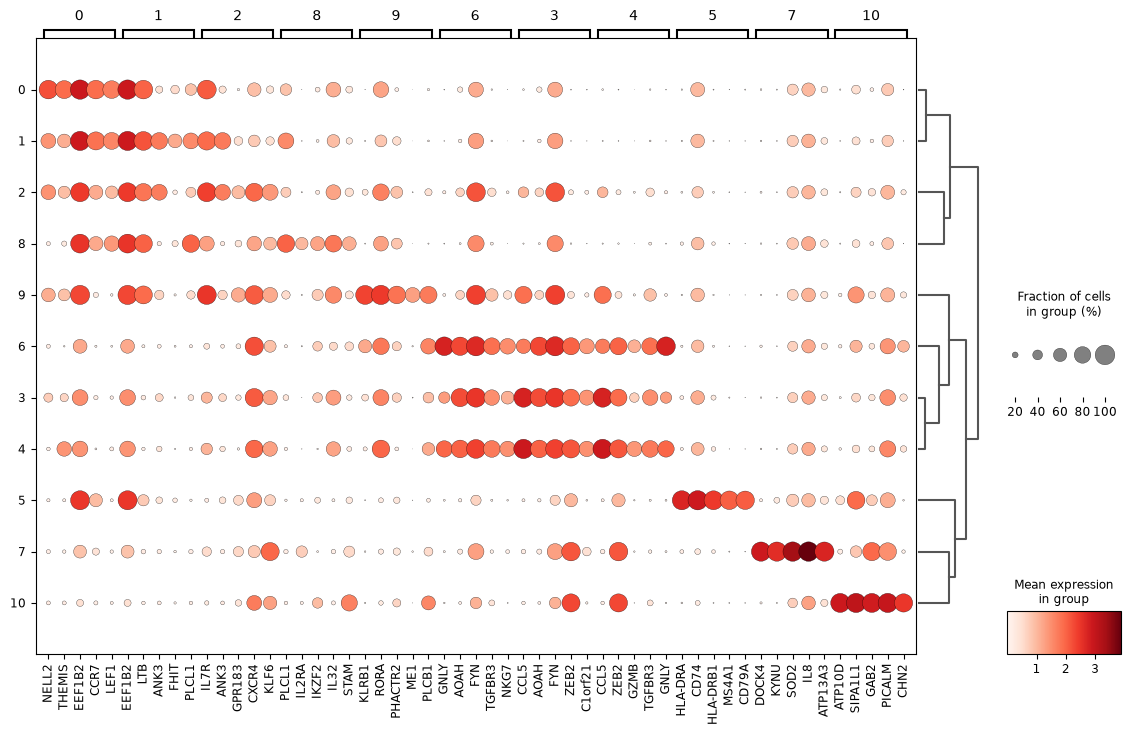


✓ Marker genes dot plot generated


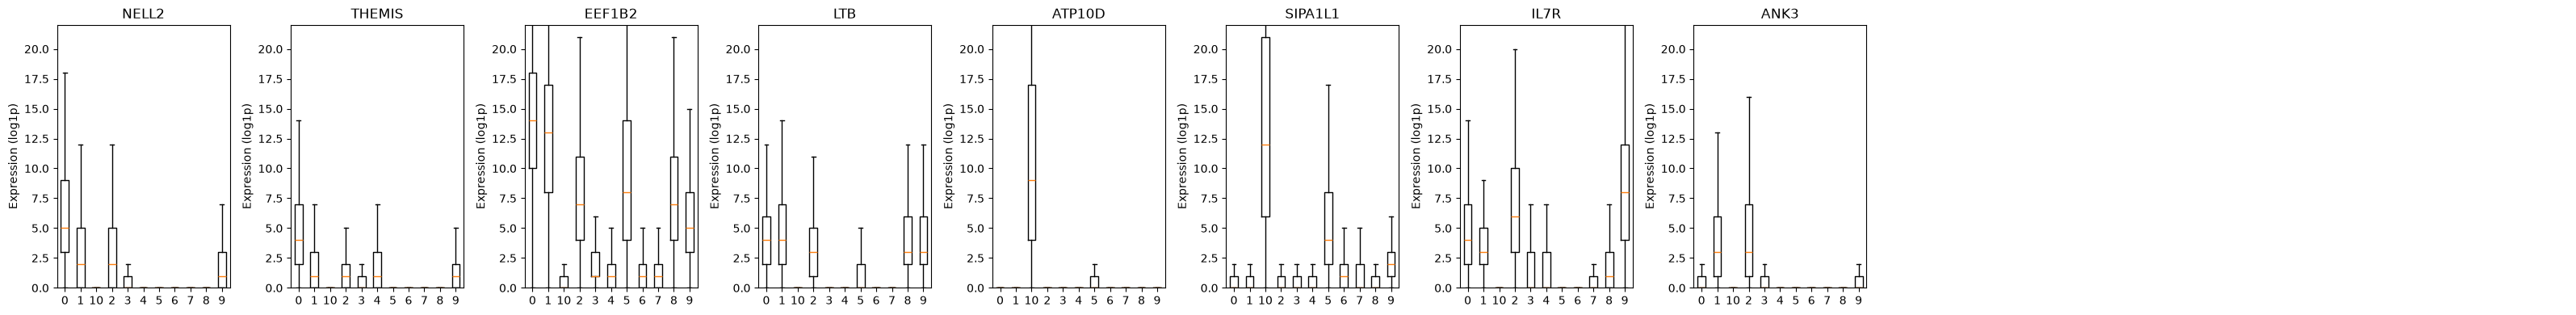


✓ Marker genes plots generated
✓ All Azimuth scores calculated.
Removed shared genes: {'TRAC', 'CD3D', 'HLA-DQA1', 'CD3G', 'CD74', 'TMSB10', 'CST7', 'TYROBP', 'NKG7'}
✓ All Azimuth scores calculated.
        Mono     CD4 T     CD8 T        NK         B   other T        DC  \
2   0.290047  2.094733  0.169938  0.113102  0.117817  0.288977  0.147642   
4   0.244988  0.610723  0.818324  0.848890  0.143560  0.643592  0.310114   
3   0.320632  0.646180  0.602895  0.707301  0.160426  0.741712  0.328789   
0   0.211888  2.048357  0.494308  0.020841  0.154727  0.035279  0.156357   
1   0.217794  2.049634  0.022049  0.016532  0.155576  0.040276  0.146352   
8   0.255524  1.658143  0.021254  0.040119  0.139094  0.070726  0.203517   
6   0.502996  0.256883  0.280140  1.205980  0.162129  0.725619  0.187328   
5   0.303892  0.491197  0.038103  0.040717  1.963211  0.051237  1.842664   
9   0.270622  2.204547  0.475705  0.245112  0.141368  0.911312  0.168123   
7   1.036678  0.386825  0.032297  0.393

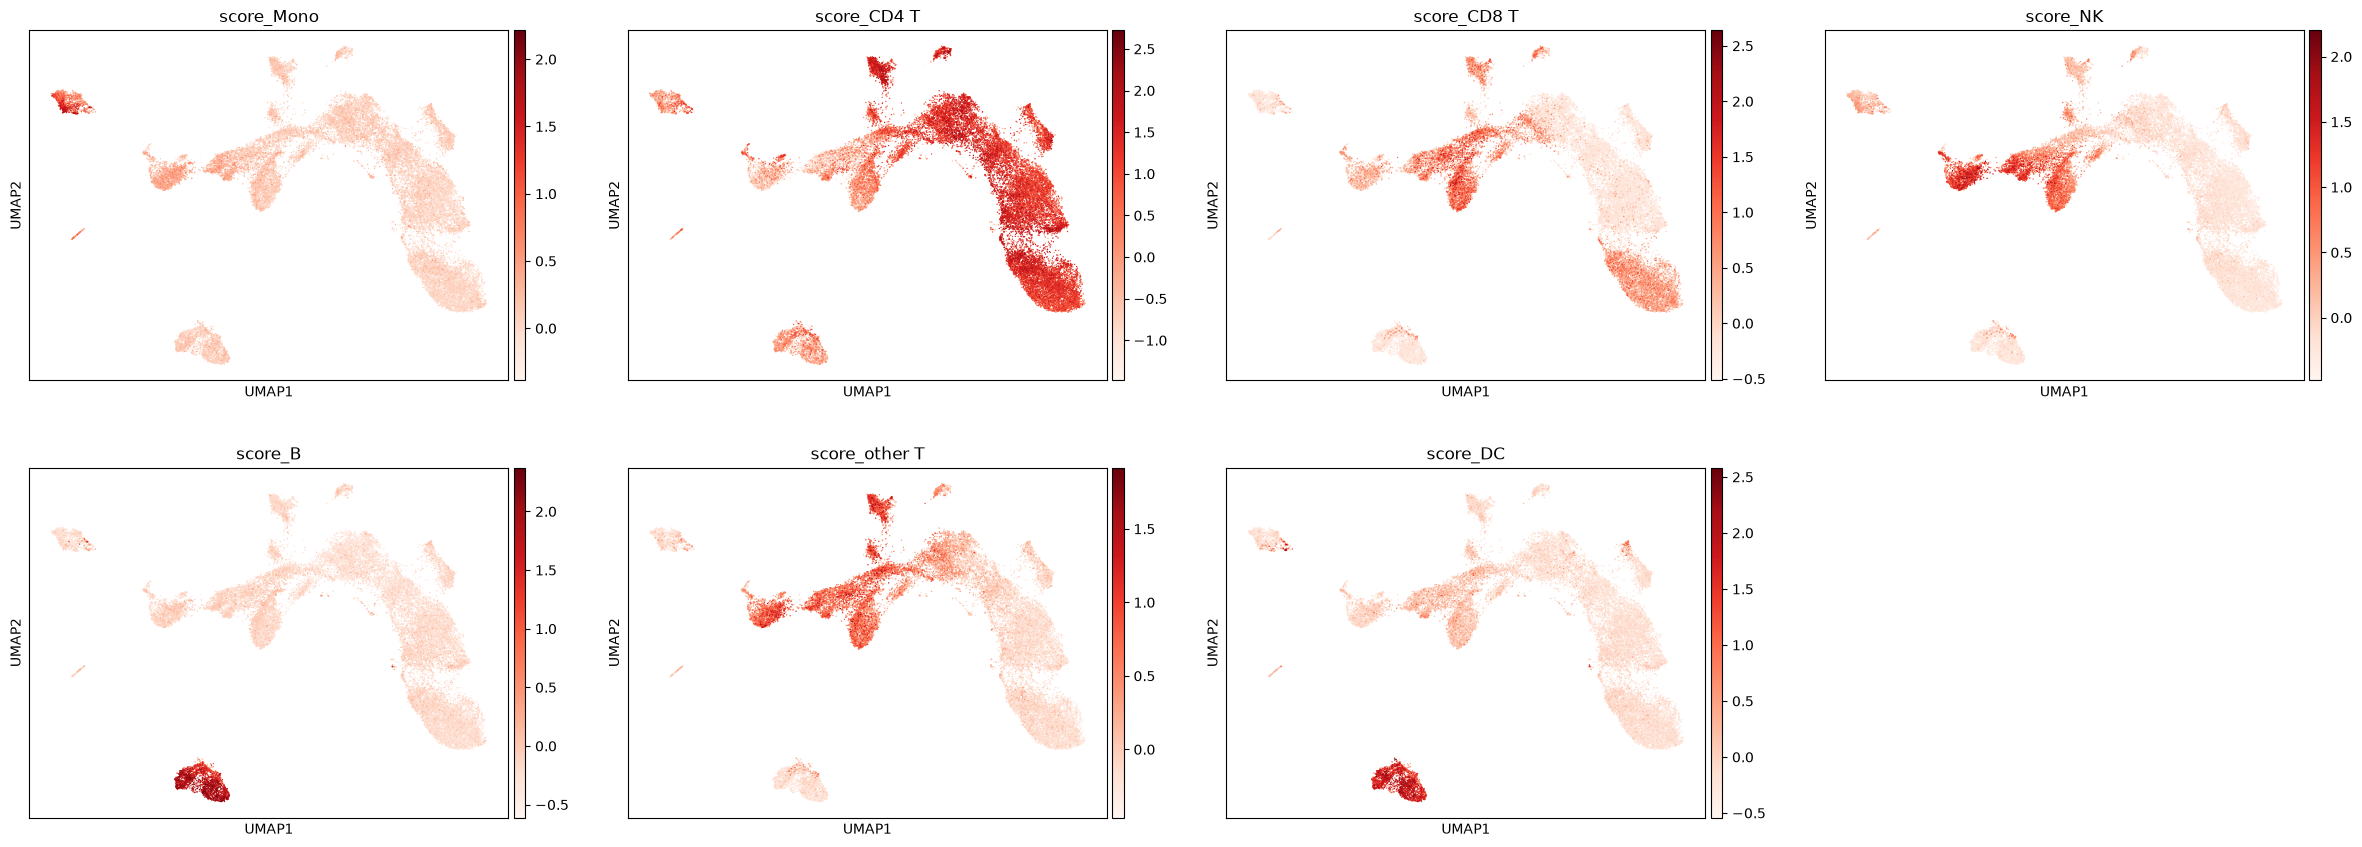

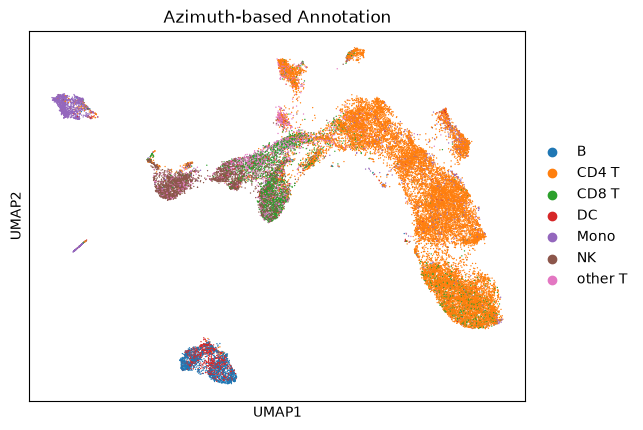

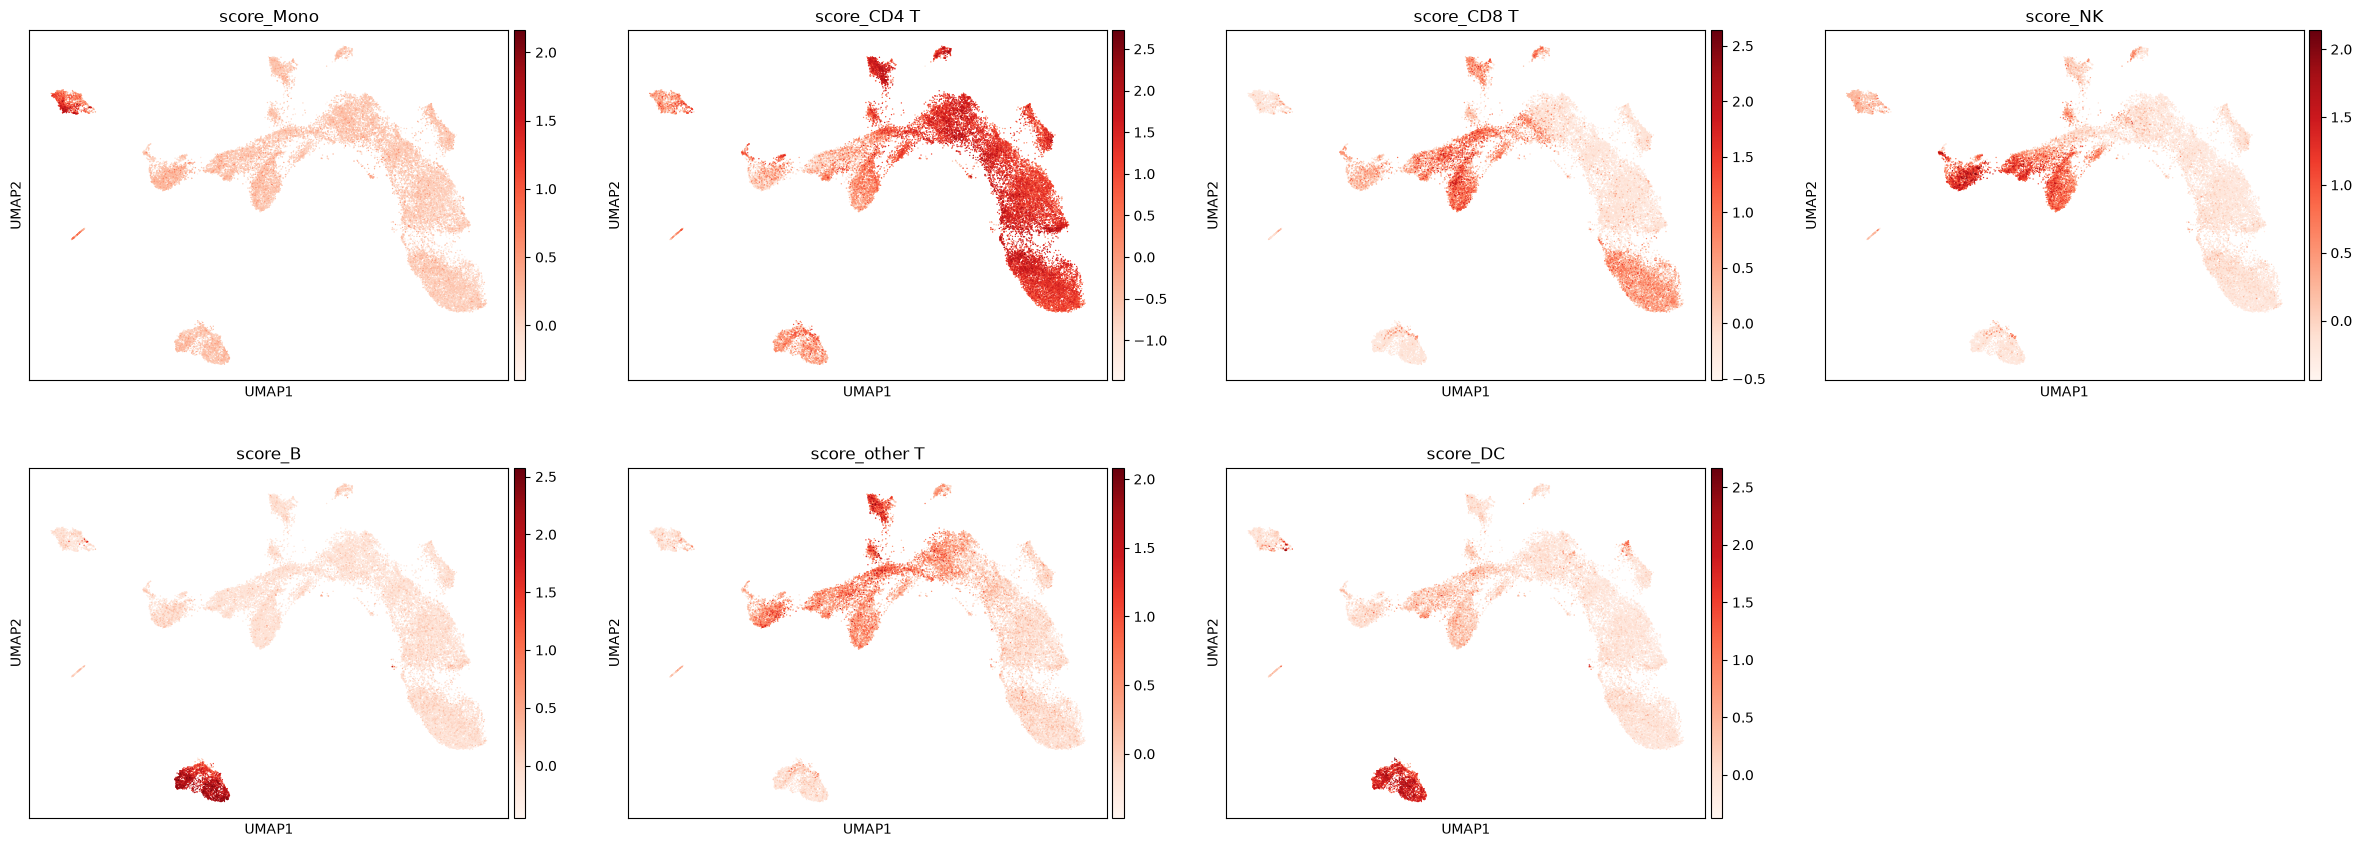

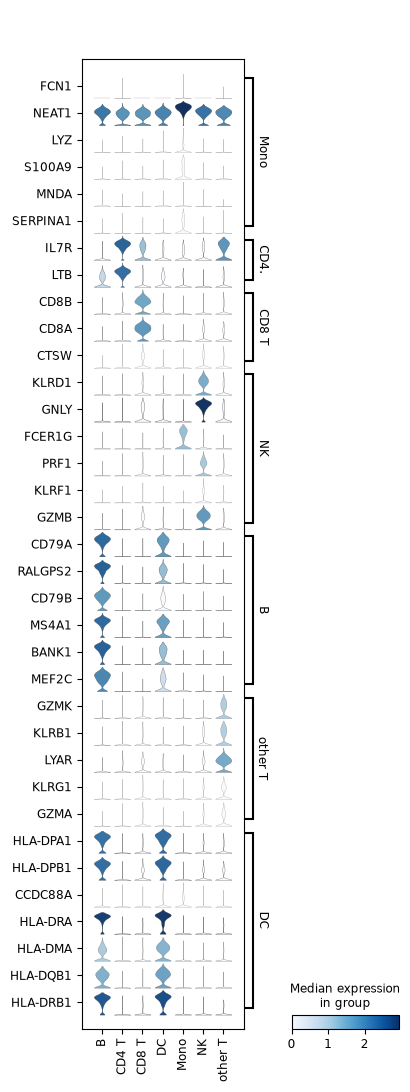

In [7]:
adata = sc.read_h5ad('data/adata_clustered.h5ad')

# Overview plot of top marker genes
sc.pl.rank_genes_groups(
    adata,
    n_genes=20,
    sharey=False,
    key='rank_genes_leiden',
    show=False
)

plt.savefig('results/marker_genes.png', bbox_inches='tight')
plt.close()

print("\n✓ Marker genes overview plot generated")
# Extract marker genes as a DataFrame
marker_genes_df = sc.get.rank_genes_groups_df(
    adata,
    group=None,  # Get markers for all groups
    key='rank_genes_leiden'
)

print("\nTop 5 marker genes per cluster:")
print("="*80)

for cluster in sorted(adata.obs['leiden'].unique()):
    cluster_markers = marker_genes_df[
        marker_genes_df['group'] == cluster
    ].head(5)

    print(f"\nCluster {cluster}:")
    for idx, row in cluster_markers.iterrows():
        print(f"  {row['names']:15s} | score: {row['scores']:6.2f} | "
              f"logFC: {row['logfoldchanges']:6.2f} | p-val: {row['pvals']:.2e}")
# Heatmap of top marker genes
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=10,
    key='rank_genes_leiden',
    groupby='leiden',
    show_gene_labels=True,
    figsize=(12, 10),
    dendrogram=False,
    show=True
)

print("\n✓ Marker genes heatmap generated")
# Dot plot of top marker genes
sc.tl.dendrogram(adata, groupby='leiden')
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=5,
    key='rank_genes_leiden',
    groupby='leiden',
    figsize=(14, 8),
    show=True
)

print("\n✓ Marker genes dot plot generated")
# Get top 3 marker genes for all clusters for violin plots
top_genes = []
for cluster in sorted(adata.obs['leiden'].unique()):  # All clusters
    cluster_markers = marker_genes_df[
        marker_genes_df['group'] == cluster
    ].head(2)
    top_genes.extend(cluster_markers['names'].tolist())

# Remove duplicates while preserving order
top_genes = list(dict.fromkeys(top_genes))[:8]  # Limit to 8 genes

# Violin plot
if len(top_genes) > 0:
    genes = top_genes
    clusters = sorted(adata.obs['leiden'].unique())

    # Choose expression source:
    # - adata.X        → usually log1p-normalized
    # - adata.layers[normlog]    → if log1p stored
    # - adata.layers[] → e.g. 'counts'
    gene_idx = [adata.var_names.get_loc(g) for g in genes]
    X = adata.layers["counts"][:, gene_idx]

    # Convert sparse to dense if needed
    if hasattr(X, "toarray"):
        X = X.toarray()

    # Build expression DataFrame
    expr = pd.DataFrame(
        X,
        columns=genes,
        index=adata.obs['leiden']
    )

    # -----------------------------
    # Plot: boxplots in a grid
    # -----------------------------
    n_genes = len(genes)
    n_cols = len(adata.obs['leiden'].unique())
    n_rows = int(np.ceil(n_genes / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(32, 4* n_rows))
    axes = axes.flatten()

    # Optional: consistent y-axis across genes
    ymax = np.percentile(expr.values, 99)

    for ax, gene in zip(axes, genes):
        data = [expr.loc[cluster, gene].values for cluster in clusters]

        ax.boxplot(
            data,
            showfliers=False
        )
        ax.set_title(gene)
        ax.set_xticks(range(1, len(clusters) + 1))
        ax.set_xticklabels(clusters, rotation=0)
        ax.set_ylabel("Expression (log1p)")
        ax.set_ylim(0, ymax)

    # Hide unused panels
    for ax in axes[len(genes):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    print("\n✓ Marker genes plots generated")
else:
    print("\n⚠ No marker genes found for violin plot")
# from https://azimuth.hubmapconsortium.org/references/

azimuth_markers = {
    "Mono": ["CTSS", "FCN1", "NEAT1", "LYZ", "PSAP", "S100A9", "AIF1", "MNDA", "SERPINA1", "TYROBP"],
    "CD4 T": ["IL7R", "MAL", "LTB", "CD4", "LDHB", "TPT1", "TRAC", "TMSB10", "CD3D", "CD3G"],
    "CD8 T": ["CD8B", "CD8A", "CD3D", "TMSB10", "HCST", "CD3G", "LINC02446", "CTSW", "CD3E", "TRAC"],
    "NK": ["NKG7", "KLRD1", "TYROBP", "GNLY", "FCER1G", "PRF1", "CD247", "KLRF1", "CST7", "GZMB"],
    "B": ["CD79A", "RALGPS2", "CD79B", "MS4A1", "BANK1", "CD74", "TNFRSF13C", "HLA-DQA1", "IGHM", "MEF2C"],
    "other T": ["CD3D", "TRDC", "GZMK", "KLRB1", "NKG7", "TRGC2", "CST7", "LYAR", "KLRG1", "GZMA"],
    "DC": ["CD74", "HLA-DPA1", "HLA-DPB1", "HLA-DQA1", "CCDC88A", "HLA-DRA", "HLA-DMA", "CST3", "HLA-DQB1", "HLA-DRB1"]
}
for cell_type, genes in azimuth_markers.items():
    # Filter the list to only genes that exist in your adata (to avoid errors)
    valid_genes = [g for g in genes if g in adata.var_names]
    
    # Run the scoring
    sc.tl.score_genes(adata, gene_list=valid_genes, score_name=f'score_{cell_type}')

print("✓ All Azimuth scores calculated.")
# Look at cell scores
sc.pl.umap(adata, color=[f'score_{cell_type}' for cell_type in azimuth_markers.keys()], cmap='Reds', show=False)
plt.savefig('results/cell_scores.png', bbox_inches='tight')
# List of the score columns we just created
score_columns = [f'score_{ct}' for ct in azimuth_markers.keys()]

# For every cell, find which score is the highest
adata.obs['predicted_type'] = adata.obs[score_columns].idxmax(axis=1)

# Clean up the names (remove 'score_')
adata.obs['predicted_type'] = adata.obs['predicted_type'].str.replace('score_', '')

# Plot the final result
sc.pl.umap(adata, color='predicted_type', title='Azimuth-based Annotation', show=False)

plt.savefig('results/azimuth_annotation.png', bbox_inches='tight')

# The "Tie-Breaker" Genes
tie_breakers = {
    'B-Cell Identity': ['CD79A', 'MS4A1', 'CD19'],
    'DC Identity': ['CST3', 'CLEC4C', 'LILRA4', 'CD1C'],
    'Shared (The Noise)': ['HLA-DRA', 'CD74']
}

sc.pl.stacked_violin(adata, tie_breakers, groupby='predicted_type', swap_axes=True, show=False)
plt.savefig('results/b_dc_diff.png', bbox_inches='tight')
plt.close()
from collections import Counter

# 1. Count how many times each gene appears across all Azimuth categories
all_genes = [gene for sublist in azimuth_markers.values() for gene in sublist]
gene_counts = Counter(all_genes)

# 2. Identify "Shared Genes" (appearing in 2 or more cell types)
# These are the genes like HLA-DRA and CD74 that cause the "speckling"
shared_genes = {gene for gene, count in gene_counts.items() if count > 1}

# 3. Create a "Cleaned" dictionary with ONLY unique markers
unique_azimuth_markers = {
    label: [gene for gene in genes if gene not in shared_genes]
    for label, genes in azimuth_markers.items()
}

# Print what we removed for your report documentation
print(f"Removed shared genes: {shared_genes}")
for cell_type, genes in unique_azimuth_markers.items():
    # Filter the list to only genes that exist in your adata (to avoid errors)
    valid_genes = [g for g in genes if g in adata.var_names]
    
    # Run the scoring
    sc.tl.score_genes(adata, gene_list=valid_genes, score_name=f'score_{cell_type}')

print("✓ All Azimuth scores calculated.")
# Look at cell scores
sc.pl.umap(adata, color=[f'score_{cell_type}' for cell_type in unique_azimuth_markers.keys()], cmap='Reds', show=False)
plt.savefig('results/cell_scores_unique.png', bbox_inches='tight')
# List of the score columns we just created
score_columns = [f'score_{ct}' for ct in unique_azimuth_markers.keys()]

# For every cell, find which score is the highest
adata.obs['predicted_type'] = adata.obs[score_columns].idxmax(axis=1)

# Clean up the names (remove 'score_')
adata.obs['predicted_type'] = adata.obs['predicted_type'].str.replace('score_', '')

# Plot the final result
sc.pl.umap(adata, color='predicted_type', title='Azimuth-based Annotation', show=False)

plt.savefig('results/azimuth_annotation_unique.png', bbox_inches='tight')
plt.close()
# 1. Get the list of genes actually present in your current adata object
available_genes = set(adata.var_names)

# 2. Filter the dictionary to remove genes that don't exist in your data
final_markers = {}
for cell_type, genes in unique_azimuth_markers.items():
    # Keep only genes that exist in the dataset
    valid = [g for g in genes if g in available_genes]
    if len(valid) > 0:
        final_markers[cell_type] = valid

sc.pl.stacked_violin(adata, final_markers, groupby='predicted_type', swap_axes=True, show=False)
plt.savefig('results/azimuth_violin.png', bbox_inches='tight')
# 1. Use the 'norm_log' layer we created (unscaled, non-negative)
# This ensures our averages are biologically meaningful
layer_to_use = "norm_log" 

# 2. Calculate the average expression of every gene for every cluster
# This is called 'Pseudobulking'
cluster_means = []
for cluster in adata.obs['leiden'].unique():
    cells_in_cluster = adata[adata.obs['leiden'] == cluster]
    # Calculate mean across the 'norm_log' layer
    mean_expr = cells_in_cluster.layers[layer_to_use].mean(axis=0)
    cluster_means.append(pd.Series(np.ravel(mean_expr), index=adata.var_names, name=cluster))

# Create a Cluster x Gene matrix
cluster_matrix = pd.concat(cluster_means, axis=1).T
# 1. Calculate a score for every Azimuth L1 category per cluster
group_scores = {}
for label, markers in azimuth_markers.items():
    # Only use genes that actually exist in our matrix
    valid_markers = [m for m in markers if m in cluster_matrix.columns]
    group_scores[label] = cluster_matrix[valid_markers].mean(axis=1)

# 2. Build a dataframe of the results
cluster_annotation_df = pd.DataFrame(group_scores)

# 3. Determine the "Winner" (Identity) for each cluster
cluster_annotation_df['final_label'] = cluster_annotation_df.idxmax(axis=1)
print(cluster_annotation_df)
# Create the mapping dictionary from the automated results
cluster_to_type = cluster_annotation_df['final_label'].to_dict()

# Apply the labels to the full dataset
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_type)
sc.pl.dotplot(
    adata, 
    final_markers, 
    groupby='cell_type', 
    standard_scale='var', 
    title="Cluster-Level Identity Verification",
    show=False
)
plt.savefig('results/dot_plot_cluster.png', bbox_inches='tight')
plt.close()

sc.pl.umap(adata, color='cell_type', title='Azimuth-based Cluster-Level Annotation', show=False)
plt.savefig('results/umap_cluster.png', bbox_inches='tight')
plt.close()

adata.write('data/adata_markers.h5ad', compression='gzip')

/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/panhumanpy/ANNotate.py:1402: UserWarning: Ensure that the features metadata is indexed with gene names.
  warnings.warn(


Integer counts detected by panhumanpy.ANNotate : False
Log-normalization performed by panhumanpy.ANNotate: False
Query object:
    Total number of cells: 31767
    Total number of features: 2487
    Overlap w. feature reference: 1106 (~21%)

Splitting query data into 4 evaluation batch(es) of up to 
8192 cells.

Interpreting label predictions for consistent granularity at broad, medium, fine level(s).

Running model:
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step
Extracting azimuth embeddings:
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


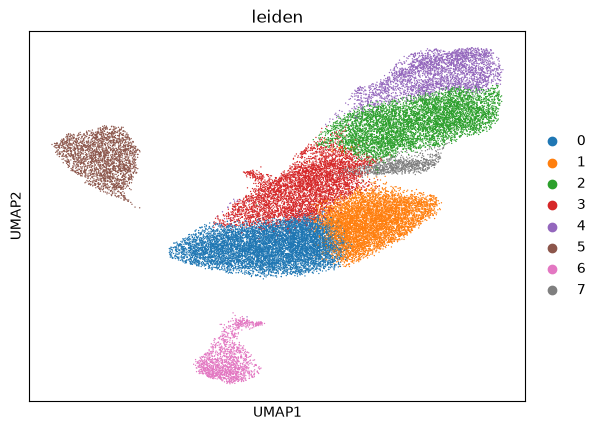

/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.3, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Mon Aug 10 12:30:41 2026 Construct fuzzy simplicial set
Mon Aug 10 12:30:41 2026 Finding Nearest Neighbors
Mon Aug 10 12:30:41 2026 Building RP forest with 14 trees
Mon Aug 10 12:30:42 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	Stopping threshold met -- exiting after 2 iterations
Mon Aug 10 12:30:48 2026 Finished Nearest Neighbor Search
Mon Aug 10 12:30:49 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Aug 10 12:31:24 2026 Finished embedding
✓ Azimuth annotation complete.
                                                       full_hierarchical_labels  \
40nm_AAACCCAAGTGGACGT-1_0            Immune cell|Lymphoid cell|T/NK cell|T cell   
40nm_AAACCCAGTATCGTGT-1_0     Immune cell|Lymphoid cell|T/NK cell|T cell|CD4...   
40nm_AAACCCAGTGCCTAAT-1_0            Immune cell|Lymphoid cell|T/NK cell|T cell   
40nm_AAACCCATCCCGAAAT-1_0            Immune cell|Lymphoid cell|T/NK cell|T cell   
40nm_AAACCCATCGTCACCT-1_0            Immune cell|Lymphoid cell|T/NK cell|T cell   
...                                                                         ...   
control_TTTGTTGGTCACAATC-1_3            

In [29]:

from panhumanpy import AzimuthNN

adata = sc.read_h5ad('data/adata_preprocessed.h5ad')

# If your .X is currently scaled, replace it with the norm_log layer
if "norm_log" in adata.layers:
    adata.X = adata.layers["norm_log"]

azimuth = AzimuthNN(adata, output_mode='detailed')

predictions = azimuth.cells_meta
adata.obs['azimuth_type'] = predictions['azimuth_broad'] # Broad categories
adata.obs['azimuth_fine'] = predictions['azimuth_fine']   # Specific subsets

embeddings = azimuth.azimuth_embed()

# 2. Put them back into your adata
adata.obsm['X_azimuth'] = embeddings

# 3. Run neighbors and Leiden on the AI's features, not your raw PCA
sc.pp.neighbors(adata, use_rep='X_azimuth')
sc.tl.leiden(adata, resolution=0.6)
sc.tl.umap(adata)

# 4. Now look at your clusters. They should be MUCH cleaner.
sc.pl.umap(adata, color='leiden')

# 3. Add the Azimuth UMAP coordinates to your object
# This allows you to show your cells in the "Reference Space"
adata.obsm['X_azimuth_umap'] = azimuth.azimuth_umap()

print("✓ Azimuth annotation complete.")

cell_metadata = azimuth.cells_meta

print(cell_metadata)

# 1. Calculate counts
counts = adata.obs['final_level_labels'].value_counts()


print("Cell counts by Final Level Label (Excluding Zeros):")
print("-" * 50)
print(counts)

# Refined mapping to preserve T-cell diversity
lineage_map_refined = {
    # Helper T-Cells
    'Naive CD4 T cell': 'CD4 T', 'CD4 T cell': 'CD4 T', 'Memory CD4 T cell': 'CD4 T',
    
    # Cytotoxic T-Cells
    'GZMB CD8 T cell': 'CD8 T', 'Memory CD8 T cell': 'CD8 T', 'GZMK CD8 T cell': 'CD8 T', 'CD8 T cell': 'CD8 T',
    
    # Regulatory and Other T
    'Treg cell': 'Treg', 'abT (entry) cell': 'Other T', 'T cell': 'Other T', 'abT cell': 'Other T',
    'KLRB1 cytotoxic CD4 T': 'Other T', 'Cycling T/NK cell': 'Other T',
    
    # The rest remain the same
    'NK cell': 'NK', 'CD16 NK cell': 'NK', 'CD56 NK cell': 'NK', 'T/NK cell': 'NK',
    'Plasma cell': 'B', 'Memory B cell': 'B', 'B cell': 'B', 'Naive B cell': 'B', 'ProB cell': 'B',
    'Monocyte': 'Mono', 'CD14 monocyte': 'Mono', 'M1 macrophage': 'Mono', 'Macrophage': 'Mono',
    'cDC2': 'DC', 'cDC': 'DC', 'cDC1': 'DC', 'Dendritic cell': 'DC',
    'Neutrophil': 'Granulocyte', 'Granulocyte': 'Granulocyte'
}

adata.obs['predicted_type'] = adata.obs['final_level_labels'].map(lineage_map_refined).fillna('Other')

# 3. Clean up categorical labels
adata.obs['predicted_type'] = adata.obs['predicted_type'].astype('category')

# Check the new counts
print(adata.obs['predicted_type'].value_counts())

adata.write('data/adata_panhuman.h5ad', compression='gzip')

In [32]:
# Save to the results folder
azimuth.cells_meta.to_csv('results/azimuth_annotations.csv', index=True)

print("✓ Metadata saved to results/azimuth_annotations.csv")

✓ Metadata saved to results/azimuth_annotations.csv


Cells remaining: 9974 out of 31767


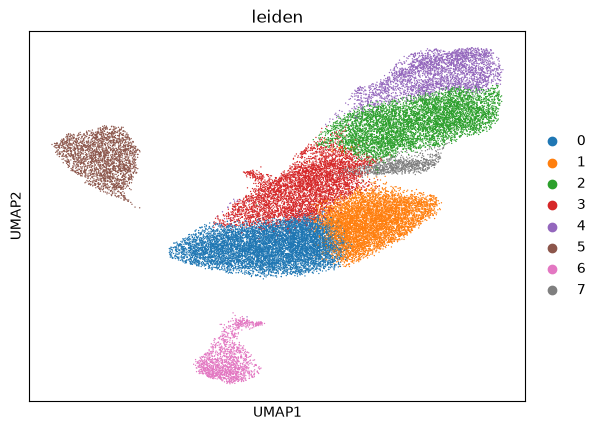

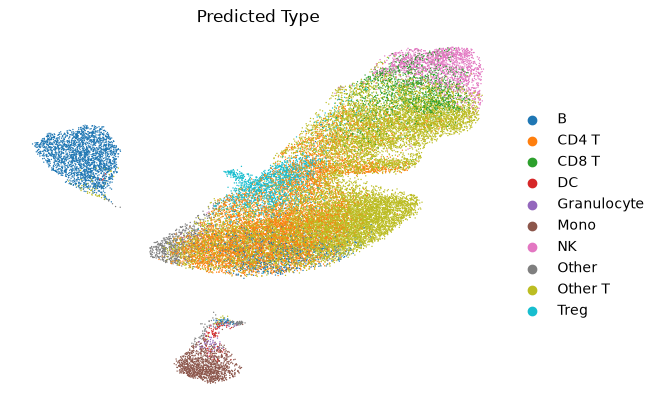

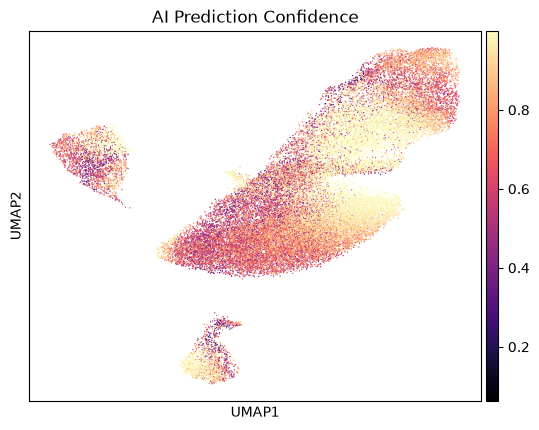

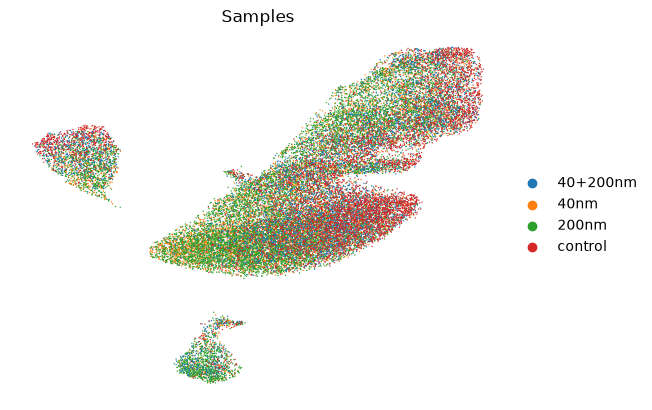

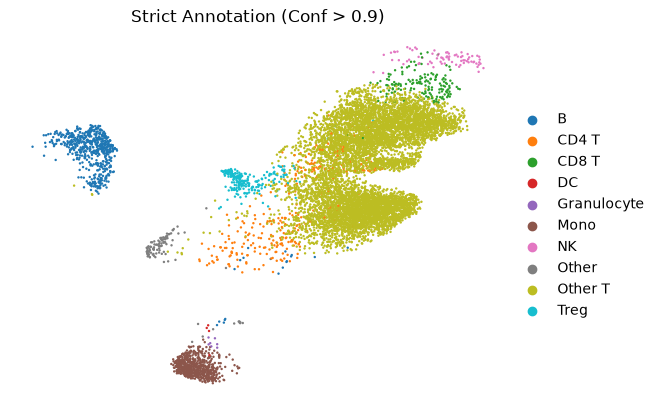

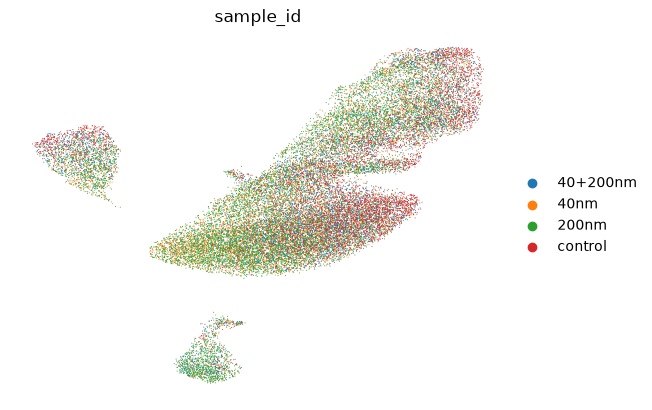

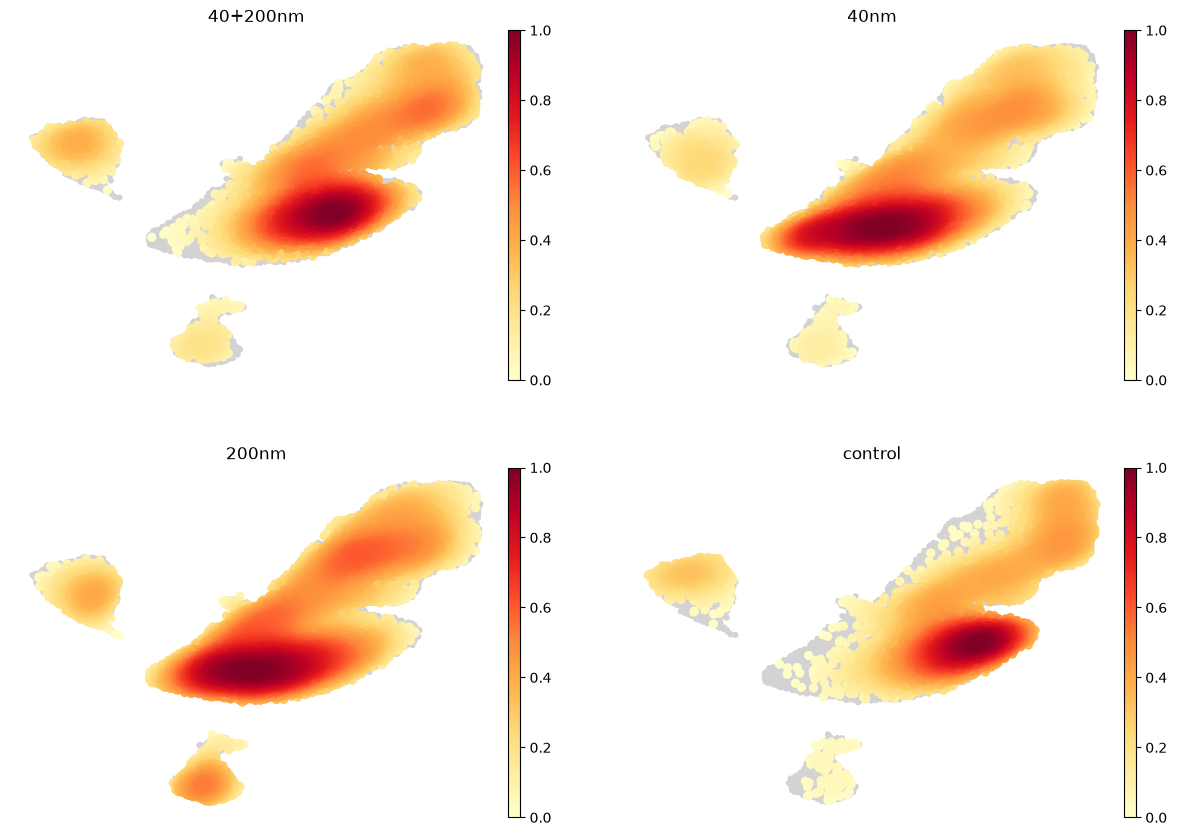

In [9]:
adata = sc.read_h5ad('data/adata_panhuman.h5ad')

sc.pl.umap(adata, color='leiden',show=False)

plt.savefig('results/panhuman_umap_leiden.png',bbox_inches='tight')

# Plot broad lineages vs. specific types
sc.pl.umap(adata, color=['predicted_type'], 
           title=['Predicted Type'],
           wspace=0.4, frameon=False, show=False)

plt.savefig('results/panhuman_umap_annotation.png', bbox_inches='tight')

# Plot the "Confidence" - This shows WHERE the AI was struggling
sc.pl.umap(adata, color='final_level_confidence', cmap='magma',
           title='AI Prediction Confidence', show=False)

plt.savefig('results/panhuman_umap_confidence.png', bbox_inches='tight')

# Plot broad lineages vs. specific types
sc.pl.umap(adata, color='sample_id',
           title=['Samples'],
           wspace=1, frameon=False, show=False)

plt.savefig('results/panhuman_umap_by_sample.png', bbox_inches='tight')
# 1. Create a temporary subset of high-confidence cells
adata_high = adata[adata.obs['final_level_confidence'] > 0.9].copy()

print(f"Cells remaining: {adata_high.n_obs} out of {adata.n_obs}")

# 2. Plot only these cells
sc.pl.umap(
    adata_high, 
    color='predicted_type', 
    title='Strict Annotation (Conf > 0.9)',
    frameon=False,
    show=False
)
plt.savefig('results/panhuman_umap_high_confidence_only.png', bbox_inches='tight')
plt.show()
# Create a 2x2 grid comparing all conditions
sc.pl.umap(
    adata, 
    color='sample_id',
    ncols=2, 
    size=2,
    frameon=False,
    show=False
)

plt.savefig('results/umap_sample_comparison_grid.png', bbox_inches='tight')
plt.show()
# This requires 'sc.tl.embedding_density'
sc.tl.embedding_density(adata, groupby='sample_id')

# Plot the density per sample
sc.pl.embedding_density(
    adata, 
    groupby='sample_id', 
    ncols=2,
    frameon=False,
    show=False
)

plt.savefig('results/umap_density_by_sample.png', bbox_inches='tight')
plt.show()

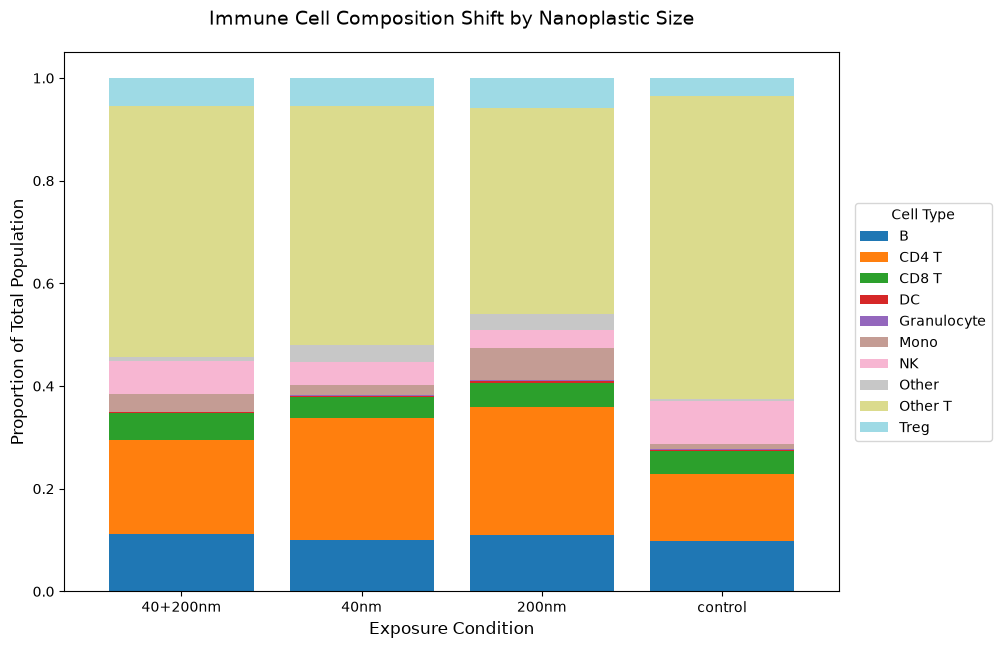

Composition Proportions:
predicted_type      B  CD4 T  CD8 T    DC  Granulocyte  Mono    NK  Other  \
sample_id                                                                   
40+200nm        11.20  18.22   5.26  0.25         0.11  3.35  6.56   0.74   
40nm            10.08  23.79   4.06  0.22         0.17  1.84  4.53   3.31   
200nm           10.90  25.00   4.69  0.38         0.26  6.21  3.44   3.18   
control          9.83  12.99   4.53  0.27         0.19  0.93  8.27   0.50   

predicted_type  Other T  Treg  
sample_id                      
40+200nm          48.93  5.39  
40nm              46.48  5.53  
200nm             40.12  5.82  
control           58.92  3.57  

Fold Change relative to Control (Value of 2.0 = Double the cells):
predicted_type     B  CD4 T  CD8 T    DC  Granulocyte  Mono    NK  Other  \
sample_id                                                                  
40+200nm        1.14   1.40   1.16  0.90         0.56  3.61  0.79   1.50   
40nm            1.02   1

<Figure size 1400x700 with 0 Axes>

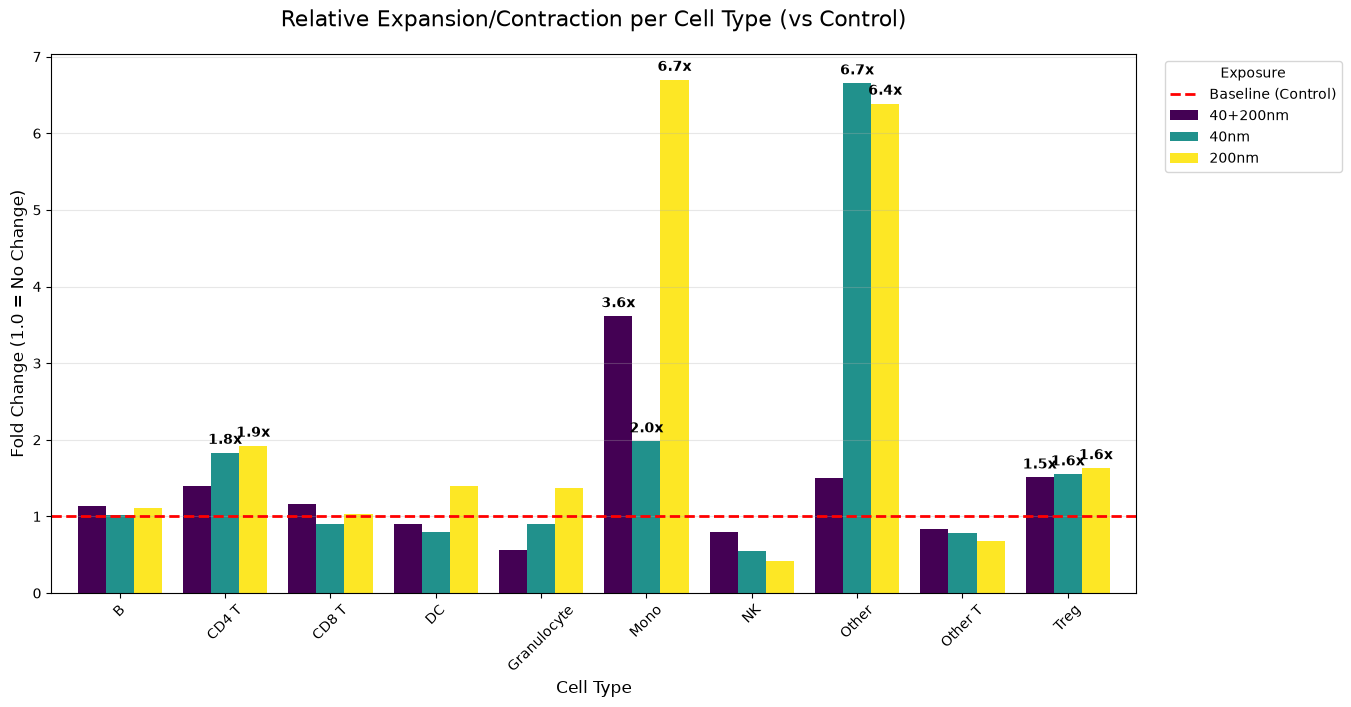

['full_hierarchical_labels', 'final_level_labels', 'final_level_confidence', 'full_consistent_hierarchy', 'level_1_labels', 'level_2_labels', 'level_3_labels', 'level_4_labels', 'level_5_labels', 'level_6_labels', 'level_7_labels', 'level_8_labels', 'azimuth_broad', 'azimuth_medium', 'azimuth_fine', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.3', 'seurat_clusters', 'predicted.id', 'prediction.score.CD14..monocyte', 'prediction.score.Dendritic.cell', 'prediction.score.Cytotoxic.T.cell', 'prediction.score.Plasmacytoid.dendritic.cell', 'prediction.score.B.cell', 'prediction.score.Natural.killer.cell', 'prediction.score.CD4..T.cell', 'prediction.score.Megakaryocyte', 'prediction.score.Unassigned', 'prediction.score.max', 'predicted.celltype.score', 'predicted.celltype', 'sample_id', 'condition', 'prediction.score.CD16..monocyte', 'sample_batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'azimuth_type', 'leiden', 'predicted_type']
AI Confidence Sta

/tmp/ipykernel_21215/3787672712.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  confidence_stats = adata.obs.groupby('sample_id')['final_level_confidence'].agg(['mean', 'median', 'std'])


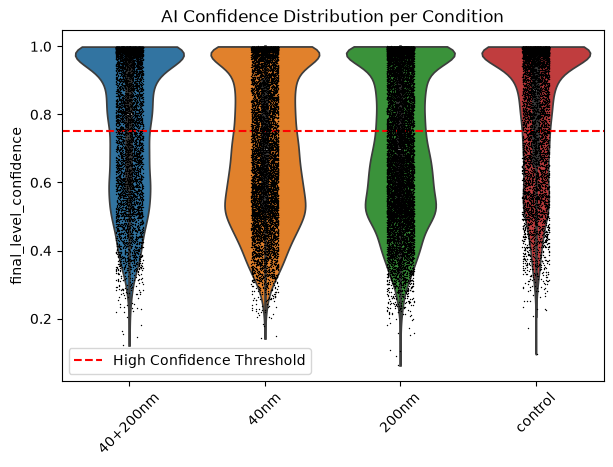

/tmp/ipykernel_21215/3787672712.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cross_check = adata.obs.groupby(['sample_id', 'predicted_type'])['final_level_confidence'].mean().unstack()


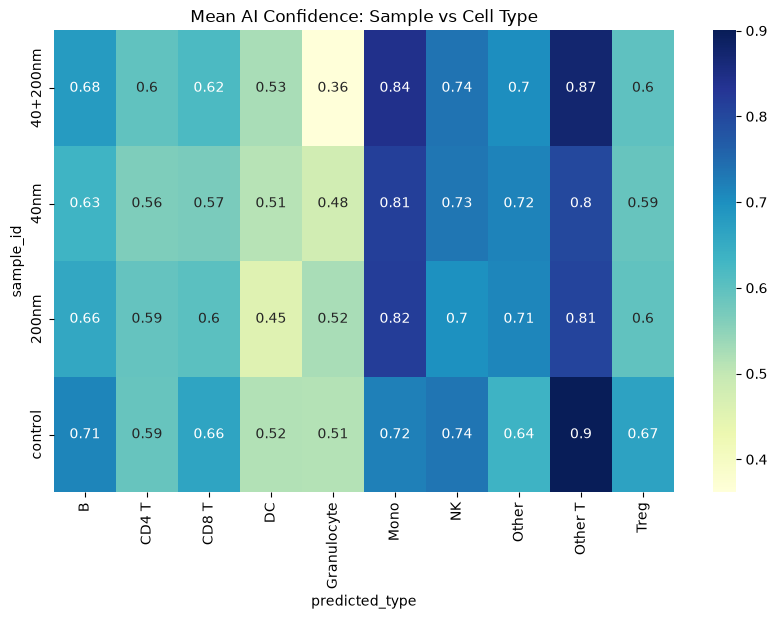

In [10]:
adata = sc.read_h5ad('data/adata_panhuman.h5ad')

import seaborn as sns

# 1. Create a contingency table (Counts of each cell type per sample)
# We use the 'predicted_type' or 'cell_type_final' column you created
counts = pd.crosstab(adata.obs['sample_id'], adata.obs['predicted_type'])

# 2. Normalize to proportions (0.0 - 1.0)
# This is critical because Sample 1 might have 8,000 cells and Sample 4 might have 6,000.
# Dividing by the sum of the row makes them comparable.
proportions = counts.div(counts.sum(axis=1), axis=0)

# 3. Create the Stacked Bar Chart
# We use a distinct colormap ('tab20' or 'Set3') to make cell types easy to distinguish
ax = proportions.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='tab20', width=0.8)

# 4. Professional Formatting
plt.title('Immune Cell Composition Shift by Nanoplastic Size', fontsize=14, pad=20)
plt.ylabel('Proportion of Total Population', fontsize=12)
plt.xlabel('Exposure Condition', fontsize=12)
plt.xticks(rotation=0) # Keeps 'control', '40nm' etc. horizontal

# Move legend outside so it doesn't cover the bars
plt.legend(title='Cell Type', bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)

# 5. Save the results
plt.savefig('results/composition_stacked_bar.png', bbox_inches='tight', dpi=300)
plt.show()

# 6. Display the raw numbers (useful for your report text)
print("Composition Proportions:")
print((proportions * 100).round(2)) # Show as percentages
# Calculate Fold Change relative to 'control'
control_row = proportions.loc['control']
fold_change = proportions.div(control_row, axis=1)

print("\nFold Change relative to Control (Value of 2.0 = Double the cells):")
print(fold_change.round(2))

# 1. Prepare the data for plotting
# We use the 'fold_change' dataframe calculated previously
# We drop 'control' because its fold change is always 1 (the baseline)
plot_df = fold_change.drop('control')

# 2. Transpose so that Cell Types are on the X-axis for better comparison
plot_df = plot_df.T

# 3. Create a Grouped Bar Chart
plt.figure(figsize=(14, 7))
ax = plot_df.plot(kind='bar', figsize=(14, 7), width=0.8, colormap='viridis')

# 4. Add a horizontal line at 1.0 (The Baseline)
# Anything above this line expanded; anything below shrank.
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Baseline (Control)')

# 5. Add text labels on top of the Monocyte bars to highlight the 6x increase
for p in ax.patches:
    if p.get_height() > 1.5: # Only label significant expansions
        ax.annotate(f'{p.get_height():.1f}x', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontweight='bold',
                    color='black')

# 6. Formatting for the presentation
plt.title('Relative Expansion/Contraction per Cell Type (vs Control)', fontsize=16, pad=20)
plt.ylabel('Fold Change (1.0 = No Change)', fontsize=12)
plt.xlabel('Cell Type', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Exposure', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)

# 7. Save the result
plt.savefig('results/population_fold_change.png', bbox_inches='tight', dpi=300)
plt.show()

# List all columns to find the confidence key
print(adata.obs.columns.tolist())
# Calculate stats per condition
confidence_stats = adata.obs.groupby('sample_id')['final_level_confidence'].agg(['mean', 'median', 'std'])

print("AI Confidence Stats by Sample:")
print(confidence_stats.round(3))
# Use Scanpy's built-in violin plot to compare distributions
sc.pl.violin(
    adata, 
    keys='final_level_confidence', 
    groupby='sample_id', 
    inner='box', 
    rotation=45,
    show=False
)

plt.title('AI Confidence Distribution per Condition')
plt.axhline(y=0.75, color='red', linestyle='--', label='High Confidence Threshold')
plt.legend()
plt.savefig('results/confidence_by_sample.png', bbox_inches='tight')
plt.show()
# Check which cell types the AI is struggling with under exposure
cross_check = adata.obs.groupby(['sample_id', 'predicted_type'])['final_level_confidence'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(cross_check, annot=True, cmap='YlGnBu')
plt.title('Mean AI Confidence: Sample vs Cell Type')
plt.savefig('results/confidence_by_sample_and_cell_type.png', bbox_inches='tight')
plt.show()

In [ ]:
'''
import gseapy as gp

adata = sc.read_h5ad('data/adata_panhuman.h5ad')

# Create folders for outputs
os.makedirs('results/DE_tables', exist_ok=True)
os.makedirs('results/Pathways', exist_ok=True)

# Define the cell types you want to analyze
cell_types = adata.obs['predicted_type'].unique()

# The conditions to compare against control
conditions = ['40nm', '200nm', '40+200nm']

# Dictionary to store results for Task 6
de_results_master = {}

for ct in cell_types:
    print(f"--- Analyzing {ct} ---")
    
    # 1. Subset to the specific cell type
    subset = adata[adata.obs['predicted_type'] == ct].copy()
    
    # 2. Run DE Analysis (Wilcoxon) using our unscaled log-layer
    sc.tl.rank_genes_groups(
        subset, 
        groupby='sample_id', 
        reference='control', 
        method='wilcoxon', 
        layer='norm_log',
        use_raw=False
    )
    
    for cond in conditions:
        # 3. Extract results into a DataFrame
        de_df = sc.get.rank_genes_groups_df(subset, group=cond)
        
        # 4. Filter for SIGNIFICANT genes (p-adj < 0.05 and logFC > 1)
        # Note: LogFC > 1 means the gene is at least 2x more expressed in the exposed sample
        sig_genes = de_df[(de_df['pvals_adj'] < 0.05) & (de_df['logfoldchanges'] > 1)]
        
        # Save table
        sig_genes.to_csv(f'results/DE_tables/{ct}_{cond}_vs_control.csv')
        
        # Store gene list for Task 6 later
        de_results_master[f"{ct}_{cond}"] = sig_genes['names'].tolist()
        
        # 5. Pathway Enrichment (if we found at least 5 genes)
        if len(sig_genes) >= 5:
            print(f"Running Enrichment for {ct} in {cond}...")
            enr = gp.enrichr(
                gene_list=sig_genes['names'].tolist(),
                gene_sets=['GO_Biological_Process_2023', 'KEGG_2021_Human', 'Reactome_2022'],
                organism='human',
                outdir=None # Keeps it in memory
            )
            
            # Save top 10 pathways
            enr.results.head(10).to_csv(f'results/Pathways/{ct}_{cond}_pathways.csv')

print("\n✓ Task 5 Computation Complete.")
'''

--- Analyzing Other T ---
Running Enrichment for Other T in 40nm...
Running Enrichment for Other T in 200nm...
Running Enrichment for Other T in 40+200nm...
--- Analyzing CD4 T ---
Running Enrichment for CD4 T in 40nm...
Running Enrichment for CD4 T in 200nm...
--- Analyzing Treg ---
Running Enrichment for Treg in 40nm...
Running Enrichment for Treg in 200nm...
--- Analyzing NK ---
Running Enrichment for NK in 40nm...
Running Enrichment for NK in 200nm...
Running Enrichment for NK in 40+200nm...
--- Analyzing B ---
Running Enrichment for B in 40nm...
Running Enrichment for B in 200nm...
--- Analyzing CD8 T ---
Running Enrichment for CD8 T in 40nm...
Running Enrichment for CD8 T in 200nm...
Running Enrichment for CD8 T in 40+200nm...
--- Analyzing Other ---
Running Enrichment for Other in 40nm...
Running Enrichment for Other in 200nm...
--- Analyzing Mono ---
Running Enrichment for Mono in 40nm...
Running Enrichment for Mono in 200nm...
Running Enrichment for Mono in 40+200nm...
--- Ana

In [45]:
names = gp.get_library_name()
# Search for KEGG and Reactome in the list
print([n for n in names if 'KEGG' in n or 'Reactome' in n])

['KEGG_2013', 'KEGG_2015', 'KEGG_2016', 'KEGG_2019_Human', 'KEGG_2019_Mouse', 'KEGG_2021_Human', 'KEGG_2026', 'Reactome_2022', 'Reactome_Pathways_2024']


In [34]:
import gseapy as gp

adata = sc.read_h5ad('data/adata_panhuman.h5ad')

# Define the cell types you want to analyze
cell_types = adata.obs['predicted_type'].unique()

# The conditions to compare against control
conditions = ['40nm', '200nm', '40+200nm']

# Dictionary to store results for Task 6
de_results_master = {}

for ct in cell_types:
    print(f"--- Analyzing {ct} ---")
    
    # 1. Subset to the specific cell type
    subset = adata[adata.obs['predicted_type'] == ct].copy()
    
    # 2. Run DE Analysis (Wilcoxon) using our unscaled log-layer
    sc.tl.rank_genes_groups(
        subset, 
        groupby='sample_id', 
        reference='control', 
        method='wilcoxon', 
        layer='norm_log',
        use_raw=False
    )
    
    for cond in conditions:
        # 3. Extract results into a DataFrame
        de_df = sc.get.rank_genes_groups_df(subset, group=cond)
        
        # 4. Filter for SIGNIFICANT genes (p-adj < 0.05 and logFC > 1)
        # Note: LogFC > 1 means the gene is at least 2x more expressed in the exposed sample
        sig_genes = de_df[(de_df['pvals_adj'] < 0.05) & (de_df['logfoldchanges'] > 1)]
        
        # Save table
        sig_genes.to_csv(f'results/DE_tables/{ct}_{cond}_vs_control.csv')
        
        # Store gene list for Task 6 later
        de_results_master[f"{ct}_{cond}"] = sig_genes['names'].tolist()
        
        # 5. Pathway Enrichment (if we found at least 5 genes)
        if len(sig_genes) >= 5:
            print(f"Running Enrichment for {ct} in {cond}...")
            enr = gp.enrichr(
                gene_list=sig_genes['names'].tolist(),
                gene_sets=['GO_Biological_Process_2023', 'KEGG_2021_Human', 'Reactome_2022'],
                organism='human',
                outdir=None # Keeps it in memory
            )
            
            # Extract the top 10 from EACH database
            top_go = enr.results[enr.results['Gene_set'] == 'GO_Biological_Process_2023'].head(10)
            top_kegg = enr.results[enr.results['Gene_set'] == 'KEGG_2021_Human'].head(10)
            top_reactome = enr.results[enr.results['Gene_set'] == 'Reactome_2022'].head(10)

            # Combine them for a balanced report
            balanced_report = pd.concat([top_go, top_kegg, top_reactome])

            # Save this version
            balanced_report.to_csv(f'results/Pathways/{ct}_{cond}_balanced_pathways.csv')



--- Analyzing Other T ---
Running Enrichment for Other T in 40nm...
Running Enrichment for Other T in 200nm...
Running Enrichment for Other T in 40+200nm...
--- Analyzing CD4 T ---
Running Enrichment for CD4 T in 40nm...
Running Enrichment for CD4 T in 200nm...
--- Analyzing Treg ---
Running Enrichment for Treg in 40nm...
Running Enrichment for Treg in 200nm...
--- Analyzing NK ---
Running Enrichment for NK in 40nm...
Running Enrichment for NK in 200nm...
Running Enrichment for NK in 40+200nm...
--- Analyzing B ---
Running Enrichment for B in 40nm...
Running Enrichment for B in 200nm...
--- Analyzing CD8 T ---
Running Enrichment for CD8 T in 40nm...
Running Enrichment for CD8 T in 200nm...
Running Enrichment for CD8 T in 40+200nm...
--- Analyzing Other ---
Running Enrichment for Other in 40nm...
Running Enrichment for Other in 200nm...
--- Analyzing Mono ---
Running Enrichment for Mono in 40nm...
Running Enrichment for Mono in 200nm...
Running Enrichment for Mono in 40+200nm...
--- Ana

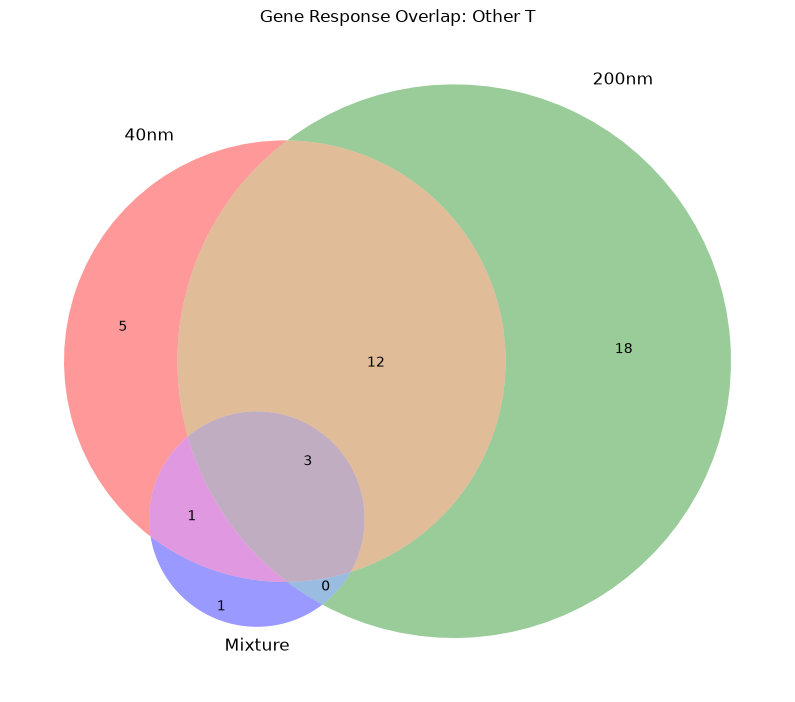

Shared: {'CXCL5', 'IL8', 'IL1B'}
Unique to 40nm: {'RN7SL1', 'METTL12', 'SNORD3A', 'DLGAP1', 'CROCC'}
Unique to 200nm: {'SOD2', 'ZNRF1', 'AGPAT4', 'C15orf48', 'S100A9', 'THBS1', 'IER3', 'IL6', 'TMLHE-AS1', 'EREG', 'CXCL1', 'NCS1', 'PTGS2', 'PID1', 'IL2RB', 'SLC7A5', 'CCL2', 'GNLY'}
Emergent Genes in Mixture: {'DDIT4'}


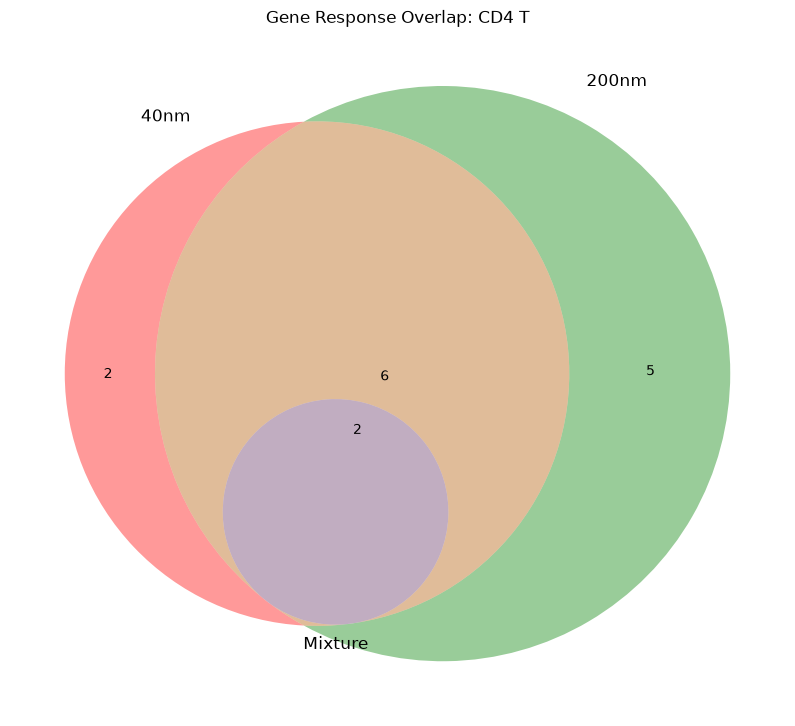

Shared: {'IL8', 'IL1B'}
Unique to 40nm: {'CROCC', 'RN7SL1'}
Unique to 200nm: {'C15orf48', 'IER3', 'THBS1', 'CXCL1', 'SOD2'}
Emergent Genes in Mixture: set()


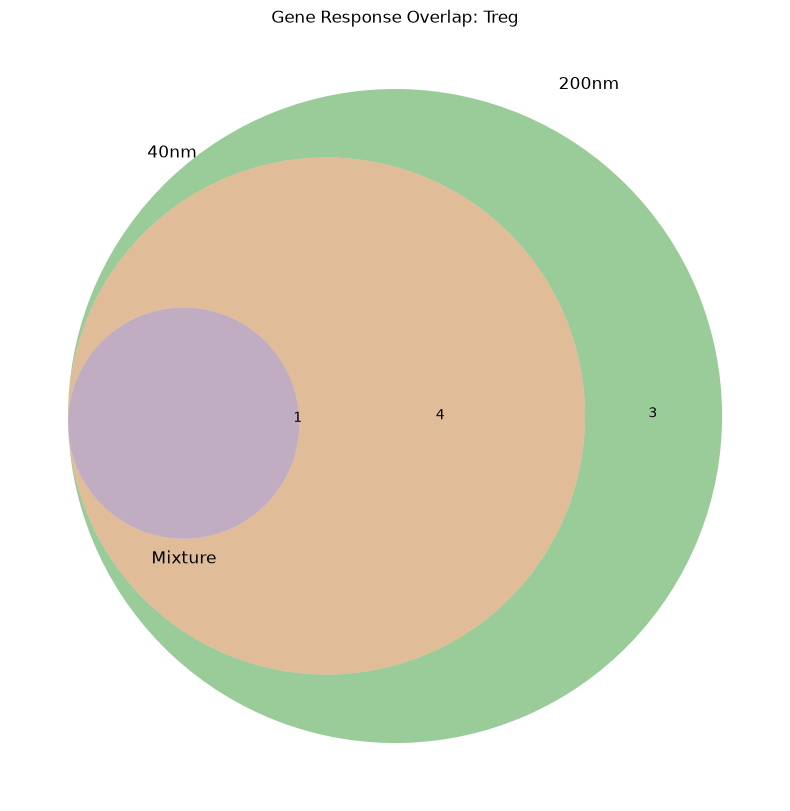

Shared: {'IL8'}
Unique to 40nm: set()
Unique to 200nm: {'CCL3', 'SOD2', 'AUTS2'}
Emergent Genes in Mixture: set()


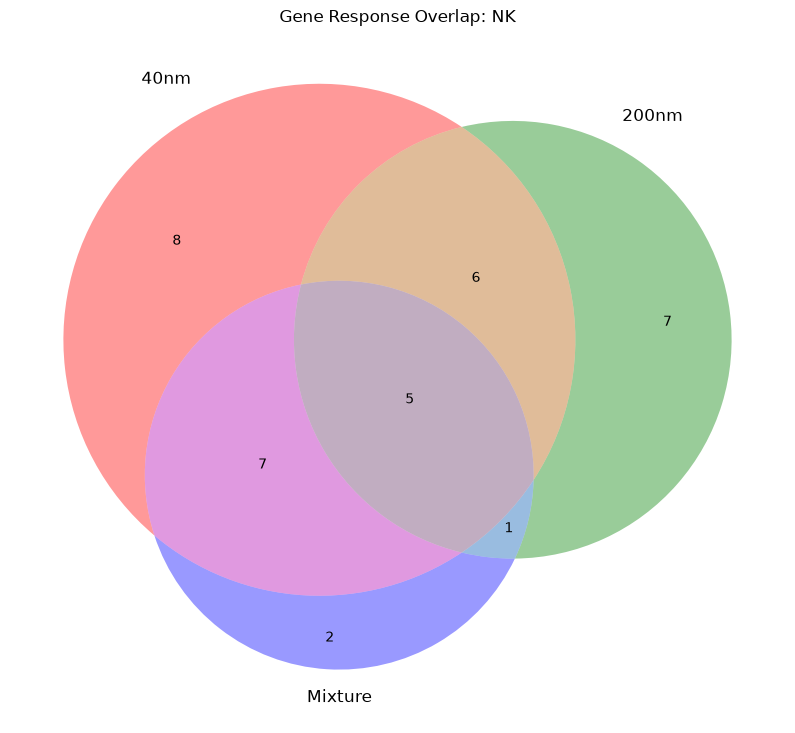

Shared: {'CREM', 'DDIT4', 'NCS1', 'IL8', 'SLC7A5'}
Unique to 40nm: {'TNFAIP3', 'RN7SL1', 'TMEM241', 'WDR74', 'PLXND1', 'CROCC', 'DUSP4', 'SLA2'}
Unique to 200nm: {'ZNRF1', 'CXCL1', 'GRK5', 'FAM46C', 'HIF1A-AS2', 'CXCL3', 'SOD2'}
Emergent Genes in Mixture: {'SYTL3', 'CEBPB'}


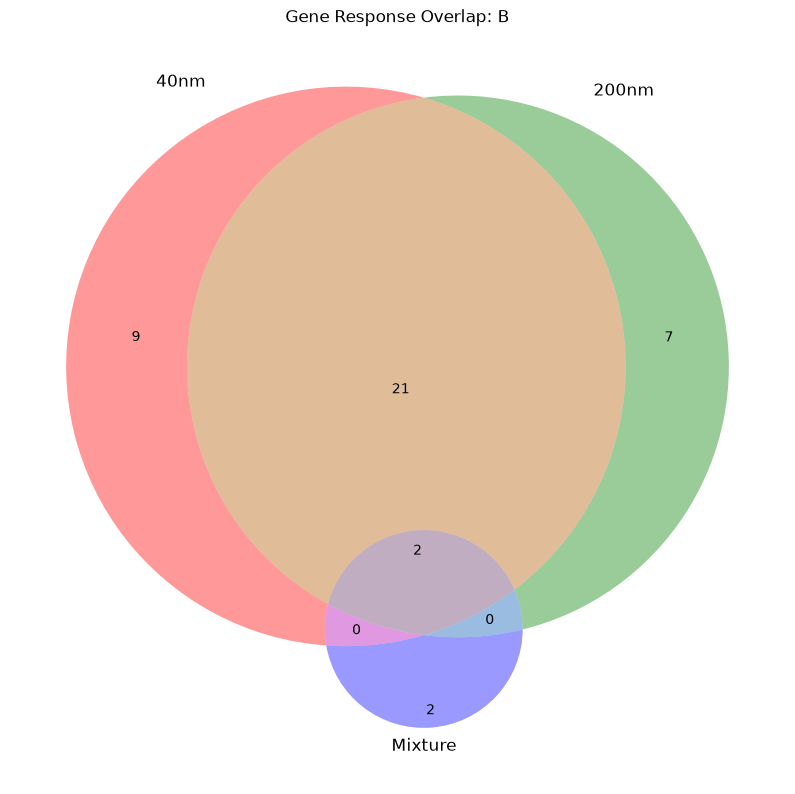

Shared: {'IL8', 'IL1B'}
Unique to 40nm: {'RN7SL1', 'PLCL1', 'PITPNC1', 'GRAP2', 'CD7', 'MLLT3', 'CD96', 'CROCC', 'SERINC5'}
Unique to 200nm: {'CCL3', 'MT2A', 'CXCL1', 'PFKFB3', 'CXCL2', 'CXCL3', 'RUNX2'}
Emergent Genes in Mixture: {'ROR1', 'RP11-452H21.1'}


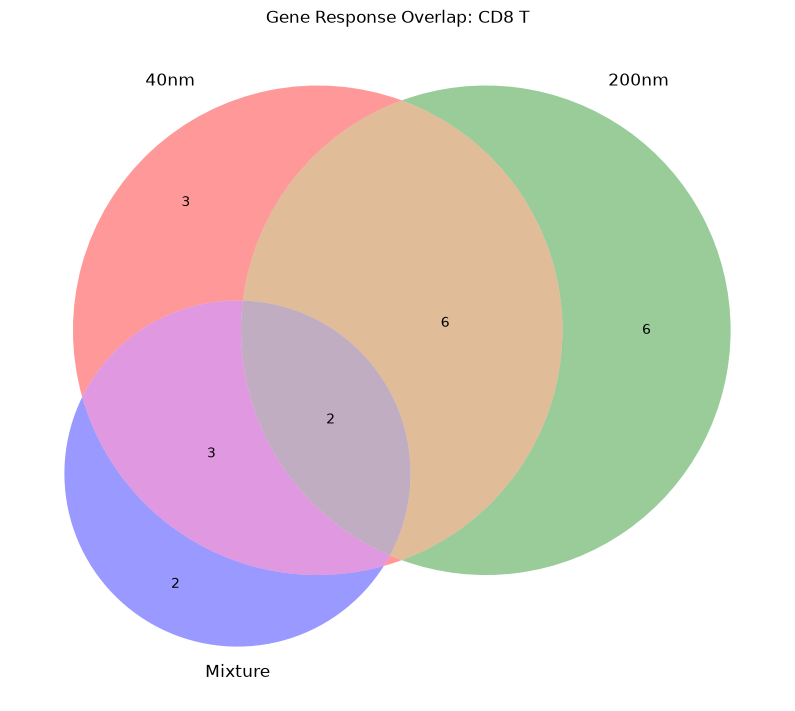

Shared: {'IL8', 'CREM'}
Unique to 40nm: {'CROCC', 'RN7SL1', 'PFKFB3'}
Unique to 200nm: {'ZNRF1', 'ANKUB1', 'CCL3', 'CXCL1', 'NEAT1', 'SERPINB2'}
Emergent Genes in Mixture: {'DDIT4', 'DOCK5'}


/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


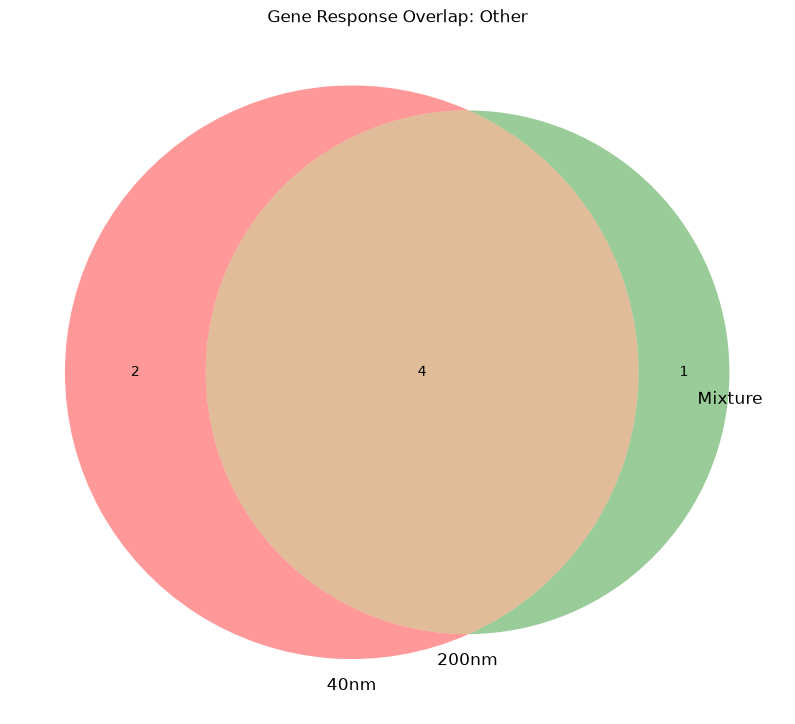

Shared: set()
Unique to 40nm: {'CD7', '7SK.2'}
Unique to 200nm: {'IL7R'}
Emergent Genes in Mixture: set()


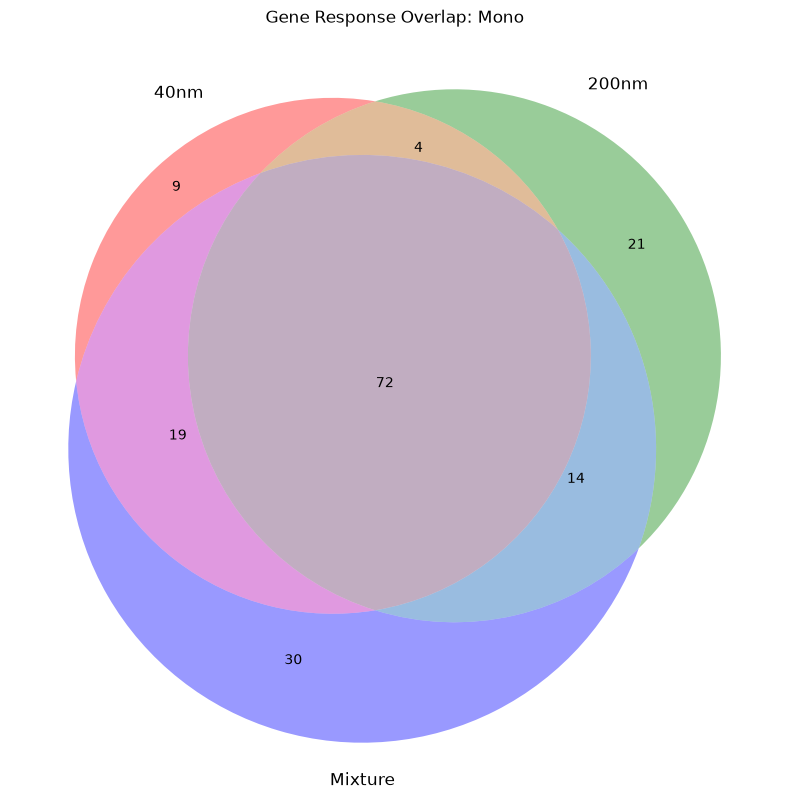

Shared: {'ITGA1', 'OGFRL1', 'RNF144B', 'PAPSS2', 'THBS1', 'CCL20', 'PTGS2', 'PAPLN', 'EPB41L3', 'HIF1A-AS2', 'TNFAIP6', 'LYN', 'DENND5A', 'MMP1', 'ARMC9', 'ATP2B1', 'NSMCE2', 'TBC1D9', 'RP11-325F22.2', 'ACSL1', 'MPZL1', 'BASP1', 'CXCL1', 'SLC7A7', 'PID1', 'IL1B', 'CTBP2', 'IRAK3', 'MIR146A', 'MCTP2', 'MGLL', 'LIMK2', 'DIAPH2', 'EBF1', 'AQP9', 'IL36G', 'ADA', 'PLD1', 'IL7', 'IL6', 'CSF3', 'G0S2', 'C3', 'CCL3', 'SLC24A3', 'SEMA3C', 'ADTRP', 'LINC00936', 'TBC1D12', 'CXCL2', 'BCL2A1', 'IL24', 'SLC25A37', 'SERPINB7', 'NEDD4L', 'CPD', 'IL10', 'IL2RA', 'DDIT4', 'SLC30A4', 'MET', 'IL1R1', 'MT2A', 'ITGB8', 'F3', 'RP11-452H21.1', 'RP11-701P16.5', 'CXCL3', 'SUPT3H', 'PDE4B', 'RUNX2', 'VNN3'}
Unique to 40nm: {'ERN1', 'GJB2', 'MMP14', 'GPR84', 'CXCL5', 'GAS7', 'MT1E', 'EDN1', 'OSM'}
Unique to 200nm: {'CEBPD', 'HIST2H2AA3', 'TNFAIP3', 'PFKFB3', 'IDO1', 'RP11-624C23.1', 'PRR16', 'SIPA1L3', 'MEGF9', 'CCL4', 'NAMPT', 'AHR', 'CD14', 'TNIP3', 'SOD2', 'CCL2', 'SLC16A10', 'SOCS3', 'ALDH1A2', 'C1orf21', 'FC

/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:97: UserWarning: All circles have zero area.
  warnings.warn("All circles have zero area.")


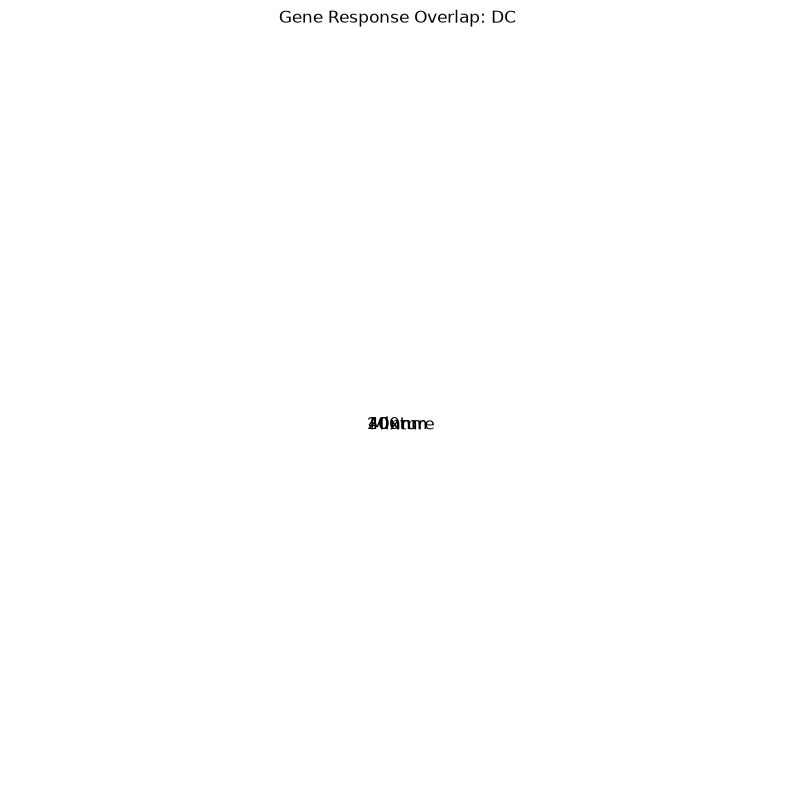

Shared: set()
Unique to 40nm: set()
Unique to 200nm: set()
Emergent Genes in Mixture: set()


/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:97: UserWarning: All circles have zero area.
  warnings.warn("All circles have zero area.")


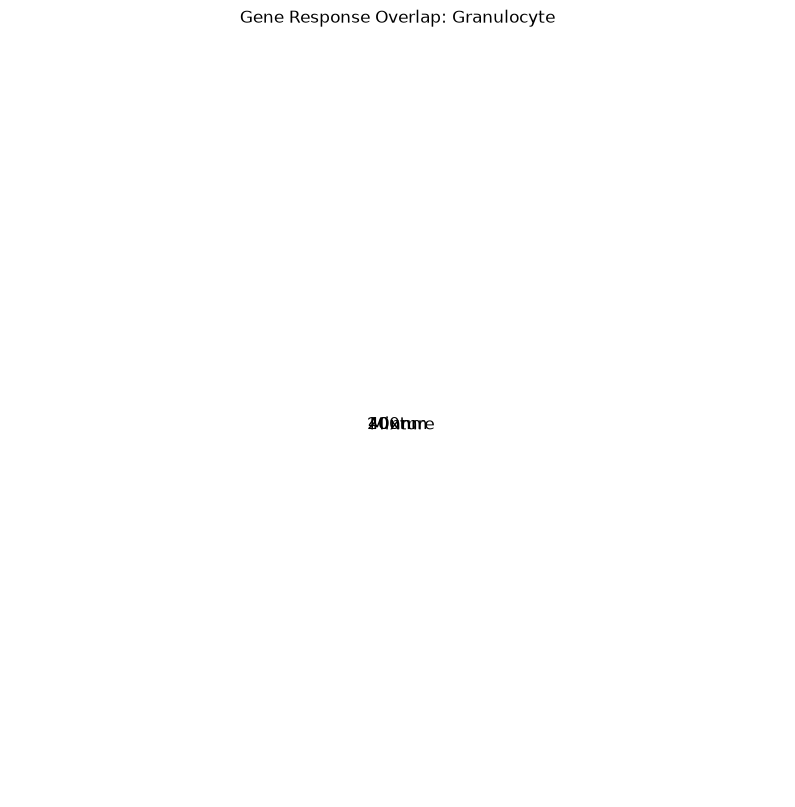

Shared: set()
Unique to 40nm: set()
Unique to 200nm: set()
Emergent Genes in Mixture: set()


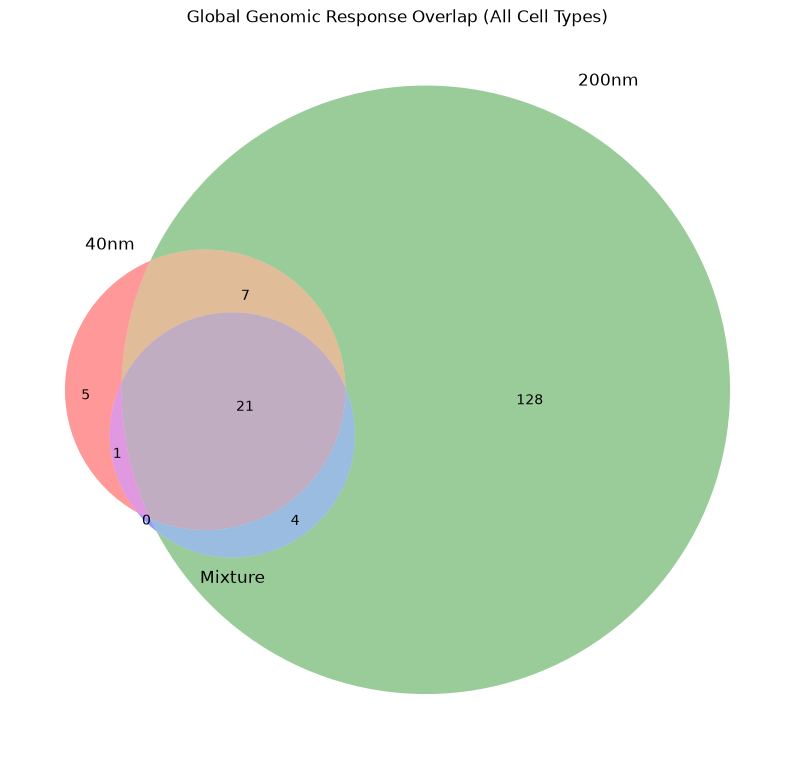

Shared: {'THBS1', 'CXCL5', 'CCL20', 'PTGS2', 'SERPINB2', 'HIF1A-AS2', 'ARMC9', 'MMP1', 'CXCL1', 'IL8', 'IL1B', 'PID1', 'CSF2', 'IL6', 'IER3', 'CXCL2', 'IL24', 'NCS1', 'ITGB8', 'RP11-452H21.1', 'CXCL3'}
Unique to 40nm: {'RP11-204L24.2', 'RN7SL1', 'METTL12', 'SNORD3A', 'CROCC'}
Unique to 200nm: {'AHRR', 'SIRPA', 'PAPSS2', 'DOCK4', 'INHBA', 'CAPG', 'SDC2', 'EPB41L3', 'PILRA', 'CDCP1', 'CCL3L1', 'TNFAIP6', 'TBC1D9', 'BASP1', 'PLAUR', 'SLC7A7', 'PHLDA1', 'PLA2G4A', 'AQP9', 'IL36G', 'RP11-519G16.3', 'GJB2', 'ZFHX3', 'C3', 'SH3PXD2B', 'WDFY3', 'SERPINB7', 'C15orf48', 'BCAT1', 'IL1A', 'ALDH1A2', 'EREG', 'EMP1', 'RP11-400N13.3', 'TNFAIP2', 'FMNL2', 'RFX8', 'NRP1', 'FCER1G', 'ITGAX', 'ZC3H12C', 'ADM', 'NCF2', 'KYNU', 'NRP2', 'S100A8', 'SPI1', 'KB-1507C5.4', 'ACSL1', 'HTR7', 'CCL3L3', 'CD68', 'CSF2RA', 'MGLL', 'BMP6', 'NDST1', 'ANGPT2', 'S100A9', 'ARHGAP22', 'GNA15', 'ADTRP', 'HCK', 'HLX', 'IL1RN', 'ANPEP', 'DMXL2', 'IL2RA', 'PLA2G7', 'SLC30A4', 'IL10', 'TREM1', 'F3', 'MPZL1', 'RP11-701P16.5', 'I

In [6]:
from matplotlib_venn import venn3 # pip install matplotlib-venn

adata = sc.read_h5ad('data/adata_panhuman.h5ad')

def get_sig_genes(adata, group, logfc_thresh=1.0, p_thresh=0.05):
    """Extracts significant gene names for a given condition."""
    df = sc.get.rank_genes_groups_df(adata, group=group)
    sig = df[(df['pvals_adj'] < p_thresh) & (df['logfoldchanges'] > logfc_thresh)]
    return set(sig['names'])


for ct in adata.obs['predicted_type'].unique():
    subset = adata[adata.obs['predicted_type'] == ct].copy()


    sc.tl.rank_genes_groups(
        subset, 
        groupby='sample_id', 
        reference='control', 
        method='wilcoxon', 
        layer='norm_log',
        use_raw=False
    )

    # 1. Define sets for a specific cell type (e.g., Monocytes)
    # We assume 'adata_mono' is the subset from Task 5
    set_40 = get_sig_genes(subset, '40nm')
    set_200 = get_sig_genes(subset, '200nm')
    set_mix = get_sig_genes(subset, '40+200nm')

    # 2. Logical Intersections
    shared_all = set_40 & set_200 & set_mix
    unique_40 = set_40 - set_200 - set_mix
    unique_200 = set_200 - set_40 - set_mix
    shared_40_200 = (set_40 & set_200) - set_mix

    # 3. Emergent Genes (The most interesting CS finding)
    # Significant ONLY in the mixture, not in either single size
    emergent_mix = set_mix - set_40 - set_200

    # 4. Visualization
    plt.figure(figsize=(10, 10))
    venn3([set_40, set_200, set_mix], ('40nm', '200nm', 'Mixture'))
    plt.title(f"Gene Response Overlap: {ct}")
    plt.savefig(f'results/venn_diagram_{ct}.png', bbox_inches='tight')
    plt.show()

    print(f"Shared: {shared_all}")
    print(f"Unique to 40nm: {unique_40}")
    print(f"Unique to 200nm: {unique_200}")
    print(f"Emergent Genes in Mixture: {emergent_mix}")

sc.tl.rank_genes_groups(
    adata, 
    groupby='sample_id', 
    reference='control', 
    method='wilcoxon', 
    layer='norm_log',
    use_raw=False
)

# 2. Extract Global Sets
global_40 = get_sig_genes(adata, '40nm')
global_200 = get_sig_genes(adata, '200nm')
global_mix = get_sig_genes(adata, '40+200nm')

# 3. Visualize Global Overlap
plt.figure(figsize=(10, 10))
venn3([global_40, global_200, global_mix], ('40nm', '200nm', 'Mixture'))
plt.title("Global Genomic Response Overlap (All Cell Types)")
plt.savefig('results/global_venn_diagram.png', bbox_inches='tight')
plt.show()

shared_all = global_40 & global_200 & global_mix
unique_40 = global_40 - global_200 - global_mix
unique_200 = global_200 - global_40 - global_mix

# Print the Global Emergent Genes (The ones that affect the whole system only in mixture)
global_emergent = global_mix - global_40 - global_200

print(f"Shared: {shared_all}")
print(f"Unique to 40nm: {unique_40}")
print(f"Unique to 200nm: {unique_200}")
print(f"Global Emergent Genes: {global_emergent}")

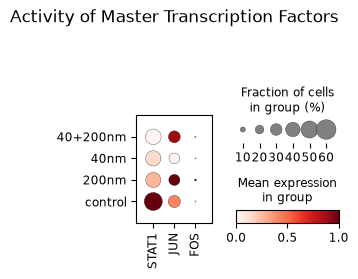

In [14]:
adata = sc.read_h5ad('data/adata_panhuman.h5ad')

# We can use Decoupler (a standard SOTA tool) or a simple proxy
# Let's focus on the expression of master regulators themselves
tfs = ['NFKB1', 'RELA', 'HIF1A', 'STAT1', 'JUN', 'FOS']
valid_tfs = [tf for tf in tfs if tf in adata.var_names]

sc.pl.dotplot(adata, valid_tfs, groupby='sample_id', standard_scale='var', 
              title='Activity of Master Transcription Factors', show=False)

plt.savefig('results/transcription_factors.png',bbox_inches='tight')

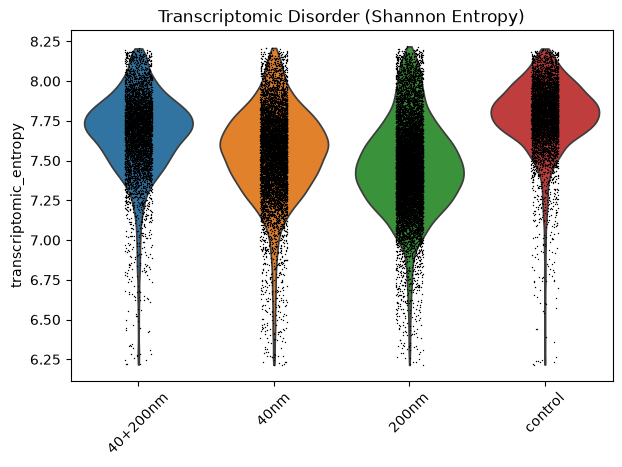

✓ Entropy calculated. Mean: 7.58


In [4]:
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt

adata = sc.read_h5ad('data/adata_panhuman.h5ad')

# 1. Calculate Shannon Entropy per cell
# We use the raw counts from adata.raw (most accurate for information theory)
raw_adata = adata.raw.to_adata()
X_raw = raw_adata.X

# Loop through cells (rows) and calculate entropy
# This is more RAM-efficient than .toarray() for 33k cells
entropies = []
for i in range(X_raw.shape[0]):
    cell_counts = X_raw[i].toarray().flatten()
    # scipy.stats.entropy handles normalization to probabilities automatically
    entropies.append(entropy(cell_counts))

adata.obs['transcriptomic_entropy'] = entropies

# 2. Fix the plotting crash
# Remove 'title' from the function call and add it via plt
sc.pl.violin(
    adata, 
    keys='transcriptomic_entropy', 
    groupby='sample_id', 
    rotation=45,
    show=False  # Crucial: This lets us customize the plot after
)

plt.title('Transcriptomic Disorder (Shannon Entropy)') # Set title safely
plt.savefig('results/transcriptomic_entropy.png', bbox_inches='tight')
plt.show()

print(f"✓ Entropy calculated. Mean: {np.mean(entropies):.2f}")

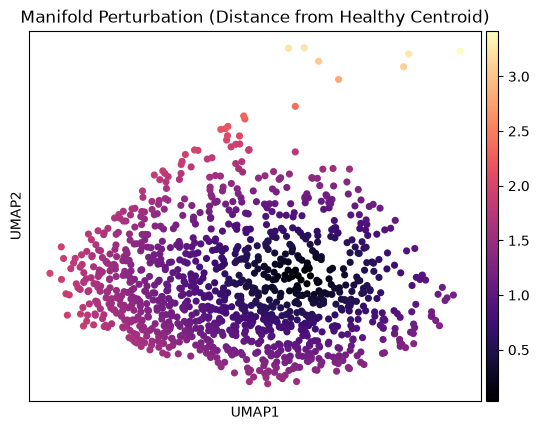

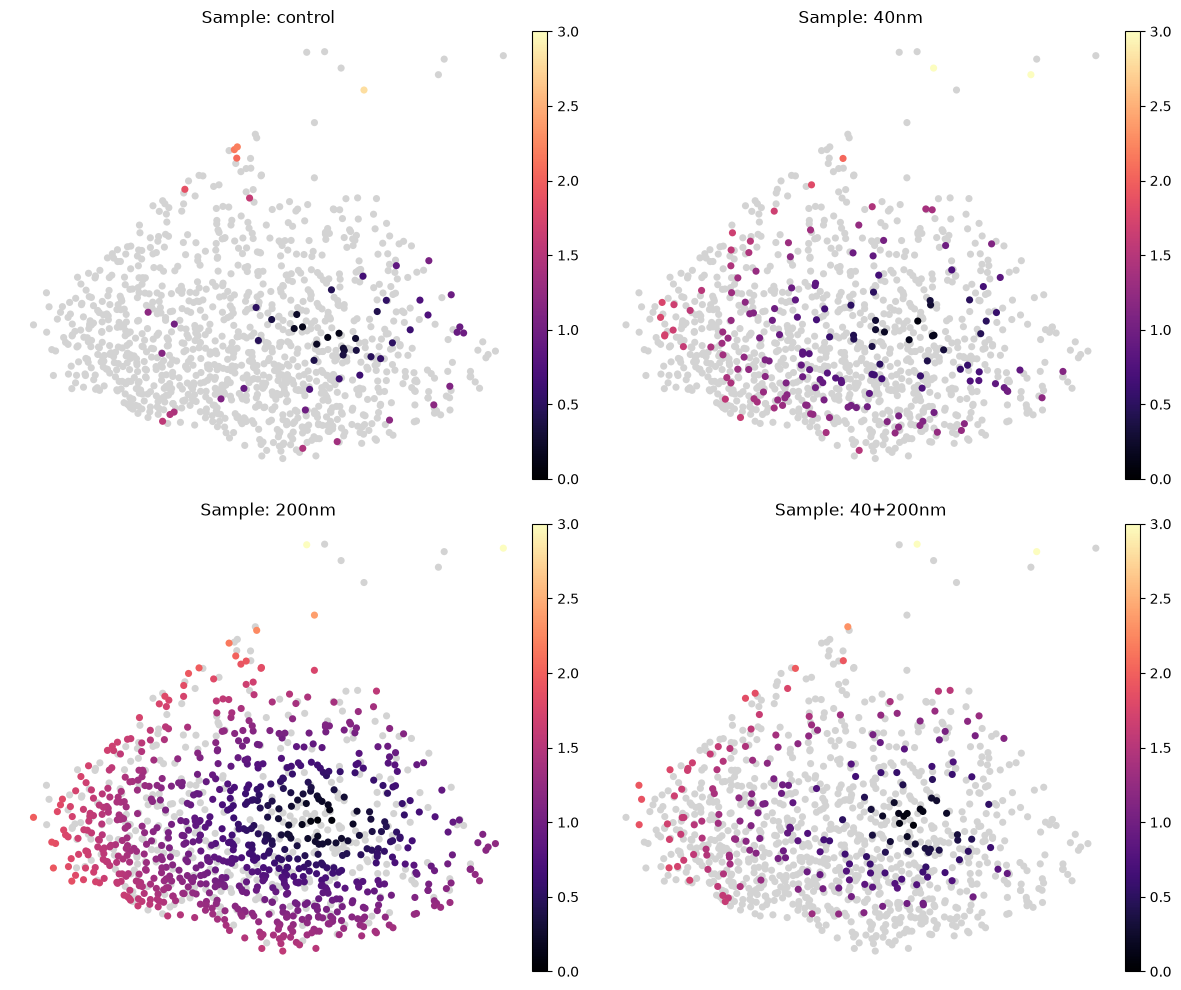

Mean Manifold Perturbation by Sample:
sample_id
40+200nm    1.060554
40nm        1.053049
200nm       1.068525
control     0.877569
Name: perturbation_dist, dtype: float32


/tmp/ipykernel_25055/2857300199.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_dist = adata_mono.obs.groupby('sample_id')['perturbation_dist'].mean()


In [11]:
adata = sc.read_h5ad('data/adata_panhuman.h5ad')

# 1. Filter for Monocytes
mono_mask = adata.obs['predicted_type'] == 'Mono'
adata_mono = adata[mono_mask].copy()

# 2. Get UMAP coordinates
coords = adata_mono.obsm['X_umap']

# 3. Calculate Centroid of the 'control' group
control_mask = (adata_mono.obs['sample_id'] == 'control').values
control_centroid = np.mean(coords[control_mask], axis=0)

# 4. Calculate Distance of every cell from the healthy center
# This is a vector magnitude calculation: || cell_pos - control_center ||
distances = np.linalg.norm(coords - control_centroid, axis=1)
adata_mono.obs['perturbation_dist'] = distances

# 5. Visualize the "Heatmap of Displacement"
sc.pl.umap(adata_mono, color='perturbation_dist', cmap='magma', 
           title='Manifold Perturbation (Distance from Healthy Centroid)', show=False)

plt.savefig('results/manifold_perturbation.png', bbox_inches='tight')

import matplotlib.pyplot as plt

# 1. Define the samples we want to show
sample_list = ['control', '40nm', '200nm', '40+200nm']

# 2. Setup the figure (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# 3. Loop through samples and draw one per window
for i, sample in enumerate(sample_list):
    # We use 'mask_obs' to only color the current sample
    # The others will be hidden or light grey
    sc.pl.umap(
        adata_mono, 
        color='perturbation_dist',
        mask_obs=(adata_mono.obs['sample_id'] == sample),
        ax=axes[i],
        show=False,
        cmap='magma',
        vmin=0, vmax=3, # Keep scale consistent across all 4 plots
        title=f"Sample: {sample}",
        frameon=False
    )

plt.tight_layout()
plt.savefig('results/perturbation_split_grid.png', bbox_inches='tight')
plt.show()

# 6. Print the summary for your slides
mean_dist = adata_mono.obs.groupby('sample_id')['perturbation_dist'].mean()
print("Mean Manifold Perturbation by Sample:")
print(mean_dist)

In [ ]:
adata = sc.read_h5ad('data/adata_panhuman.h5ad')

# Pro-inflammatory 'Alarm' Genes
cytokines = ['IL1B', 'IL6', 'TNF', 'CCL3', 'CCL4', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL5', 'IL8']
valid_cytos = [g for g in cytokines if g in adata.var_names]

sc.tl.score_genes(adata, gene_list=valid_cytos, score_name='cytokine_storm_score')
sc.pl.umap(adata, color=['predicted_type', 'cytokine_storm_score'], cmap='Reds', show=False)
plt.savefig('alarm_genes.png', bbox_inches='tight')